In [ ]:
## COV is a measure of variance from the mean sale ratio, expressed as a percentage.
## # It is calculated as the standard deviation of the sale ratio divided by the mean sale ratio, multiplied by 100.
cov <- function(df_col) {
    mean_ratio <- mean(df_col, na.rm = TRUE)
    sd_ratio <- sd(df_col, na.rm = TRUE)
    cov_value <- (sd_ratio / mean_ratio) * 100
    return(cov_value)
}


In [ ]:
## PRB is a measure of any relationship between the sale price and the sale ratio.
## It is calculated as the slope of the regression line fitted to the sale price and sale ratio data.
prb = function(df_sp,df_sr) {
    valid <- !is.na(df_sp) & !is.na(df_sr)
    df_sp <- df_sp[valid]
    df_sr <- df_sr[valid]
    if (length(df_sr) < 2) {
        return(NA)
    }
    model <- lm(df_sr ~ df_sp)
    
    prb <- coef(model)[2]
    return(prb)
}

In [ ]:
## COD is a measure of the coefficient of dispersion, which indicates the variability of the sale ratio around the median sale ratio.
## It is calculated as the mean absolute deviation from the median sale ratio, divided by the median sale ratio, multiplied by 100.
cod = function(df_col) {
    median_ratio <- median(df_col, na.rm = TRUE)
    cod <- mean(abs(df_col - median_ratio), na.rm = TRUE) / median_ratio * 100
    
    return(cod)
}

In [ ]:
## PRD is a measure of the price ratio dispersion, which indicates how the average sale price compares to the weighted average sale ratio.
## It is calculated as the mean sale ratio divided by the weighted mean sale ratio.
prd = function(df_av,df_sp,df_sr) {
mean_ratio = mean(df_sr, na.rm = TRUE)
weighted_mean_ratio = sum(df_av, na.rm = TRUE) / sum(df_sp, na.rm = TRUE)
prd = mean_ratio / weighted_mean_ratio
return (prd)
}

In [ ]:
# This function calculates the confidence interval for the median sale ratio.
# It uses bootstrapping for larger datasets and a binomial distribution for smaller datasets.
confidence_interval <- function(ratio) {
  ratio = ratio[!is.na(ratio)]
  n = length(ratio)
  alpha = .05
  
  if (n < 5) {
    return(c(NA, NA))
  } else if (n < 20) {
    sortedratio <- sort(ratio)
    k <- qbinom(alpha / 2, n, 0.5)
    lower <- sortedratio[k + 1]
    upper <- sortedratio[n - k]
    return(c(round(lower,2), round(upper,2)))
  } else {
    boot_medians <- round(replicate(1000, median(sample(ratio, replace = TRUE))),2)
    return(quantile(boot_medians, c(alpha / 2, 1 - alpha / 2)))
  }
}

In [ ]:
#Load necessary libraries
library(readxl)
library(dplyr)
library(stringr)
library(tidyr)

# Read in a file with the township groupings for each county, and create a mapping list to store these groupings
df <- read_excel("CountyMap.xlsx") %>%
  mutate(Grouping = I(strsplit(as.character(Grouping), "-")),County = str_to_sentence(County))

mapping_df <- df %>%
group_by(County, Type) %>%
summarise(Values = I(list(Grouping)), .groups = "drop")
mapping_list <- setNames(mapping_df$Values, 
                         paste(mapping_df$County, mapping_df$Type, sep = " "))



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




[[1]]
[1] "Blue Creek" "French"     "Kirkland"   "Monroe"     "St. Marys" 

[[1]]
[1] "Hartford"  "Jefferson" "Wabash"   

[[1]]
[1] "Preble" "Union" 

[[1]]
[1] "Washington"

[[1]]
[1] "Root"

[[1]]
[1] "Blue Creek" "French"     "Kirkland"   "Monroe"     "St. Marys" 

[[2]]
[1] "Hartford"  "Jefferson" "Wabash"   

[[3]]
[1] "Preble" "Union" 

[[4]]
[1] "Washington"

[[5]]
[1] "Root"



In [ ]:
# Read in the necessary files for ratio studies
wkbk23 = read.csv('tippecanoe/Combined_Workbook_2023.csv')
wkbk24 = read.csv('tippecanoe/Combined_Workbook_2024.csv')
exc23 = read.csv('tippecanoe/Combined_Reconciliation_2023.csv')
rat23 = read.csv('tippecanoe/Combined_Study_2023.csv')
exc24 = read.csv('tippecanoe/Combined_Reconciliation_2024.csv')
rat24 = read.csv('tippecanoe/Combined_Study_2024.csv')
classifications23 = read.csv('tippecanoe/Parcel_Clusters_2023.csv')
class = read.csv('tippecanoe/Parcel_Classifications_2023.csv')
ag22 = read.csv('tippecanoe/Ag_Sales_2022.csv')
ag23 = read.csv('tippecanoe/Ag_Sales_2023.csv')
ag24 = read.csv('tippecanoe/Ag_Sales_2024.csv')

In [ ]:
# Use Whitley 2024 because no data available for Whitley 2023
exc23 = rbind(exc23,exc24[exc24$County == 'Whitley',])
rat23 = rbind(rat23,rat24[rat24$County == 'Whitley',])
wkbk23 = rbind(wkbk23,wkbk24[wkbk24$County == 'Whitley',])

In [ ]:
# Define property classes for which we care about PostedSaleRatio instead of SaleRatio
posted_classes <- c(300, 400, 500, 501:509)

# Filter out sales with SalePrice less than or equal to 10,000 and those with SaleRatio or PostedSaleRatio equal to 0
exc23 <- exc23[exc23$SalePrice > 10000, ]
exc23 <- exc23[!(
  (exc23$PropertyClass %in% posted_classes & exc23$PostedSaleRatio == 0) |
  (!(exc23$PropertyClass %in% posted_classes) & exc23$SaleRatio == 0)
), ]

rat23 <- rat23[rat23$SalePrice > 10000, ]
rat23 <- rat23[!(
  (rat23$PropertyClass %in% posted_classes & rat23$PostedSaleRatio == 0) |
  (!(rat23$PropertyClass %in% posted_classes) & rat23$SaleRatio == 0)
), ]

In [ ]:
# Filter out rows with NA ParcelNumber
exc23 = exc23[!is.na(exc23$ParcelNumber),]
rat23 = rat23[!is.na(rat23$ParcelNumber),]

In [ ]:
# Create mapping between Zip, County pair and that Zip's classification
class = class %>%
group_by(Zip,County) %>%
summarise(Zip = first(Zip),County = first(County),ZipClassification = first(ZipClassification))
head(class)
nrow(class)

`summarise()` has grouped output by 'Zip'. You can override using the `.groups`
argument.


Zip,County,ZipClassification
<int>,<chr>,<chr>
40026,Clark,Urban
40059,Clark,Urban
40202,Clark,Urban
40212,Clark,Urban
40212,Floyd,Urban
40222,Clark,Urban


[1] 1275

In [ ]:
# Helper function to find the proper sales for each ratio study category
type_sales <- function(df, type) {
  if (type == 'Commercial Vacant') return(df[df$PropertyClass == 400, ])
  if (type == 'Commercial Improved') return(df[df$PropertyClass > 400 & df$PropertyClass < 500, ])
  if (type == 'Industrial Vacant') return(df[df$PropertyClass == 300, ])
  if (type == 'Industrial Improved') return(df[df$PropertyClass > 300 & df$PropertyClass < 400, ])
  if (type == 'Residential Vacant') return(df[df$PropertyClass >= 500 & df$PropertyClass < 510, ])
  if (type == 'Residential Improved') return(df[df$PropertyClass >= 510 & df$PropertyClass < 600, ])
  return(df[FALSE,])
}


In [ ]:
# Helper function to calculate ratio study statistics and confidence intervals for a subset of sales
# This function takes a data frame of sales and a boolean indicating whether to use posted sale ratios.
# It returns a list containing the median sale ratio, coefficient of dispersion (COD), coefficient of variation (COV), price ratio dispersion (PRD), price regression slope (PRB), 
# confidence interval for the median sale ratio, and the count of sales.
return_stats <- function(sales, posted) {
  if (nrow(sales) < 5) {
    return(list(median=NA, cod=NA, cov=NA, prd=NA, prb=NA, ci=c(NA, NA), count=0))
  }
  if (posted) {
    ratios <- sales$PostedSaleRatio
    avs <- sales$PostedAV
  } else {
    ratios <- sales$SaleRatio
    if (!("CurrentAV" %in% colnames(sales))) {
        avs = sales$TotalAV
    } else {
        avs <- sales$CurrentAV
    }
  }
  ci <- confidence_interval(ratios)
  list(
    median = round(median(ratios, na.rm=TRUE), 2),
    cod = round(cod(ratios), 2),
    cov = round(cov(ratios), 2),
    prd = round(prd(avs, sales$SalePrice, ratios), 2),
    prb = round(prb(sales$SalePrice, ratios), 4),
    ci = ci,
    count = nrow(sales)
  )
}


In [ ]:
library(ggplot2)
library(dplyr)
counties = unique(wkbk23$County)
clusters = unique(classifications23$Cluster)
# Define ratio study categories
types = c('Industrial Vacant','Industrial Improved','Commercial Vacant','Commercial Improved',
          'Residential Vacant','Residential Improved')
# Define what previously excluded sales belong in the aggressive and moderate studies
aggressive = c('AV DOES NOT REFLECT MARKET VALUE','MULTI PARCEL SALE','INVESTMENT/RENTAL','SOLD AS IS',
               'INSUFFICIENT TIME ON MARKET','VACANT LAND','APARTMENT','LEASE','BUILDING PERMIT',
               'NOT ENOUGH SALES FOR TRENDING')
moderate = c('AV DOES NOT REFLECT MARKET VALUE','MULTI PARCEL SALE','SOLD AS IS','INSUFFICIENT TIME ON MARKET',
              'VACANT LAND','BUILDING PERMIT','NOT ENOUGH SALES FOR TRENDING')
agdfs = list(ag22,ag23,ag24)
resultdf = data.frame(
    County = character(),
    Type = character(),
    Grouping = character(),
    LowerBound = numeric(),
    Median = numeric(),
    UpperBound = numeric(),
    COD = numeric(),
    COV = numeric(),
    PRD = numeric(),
    PRB = numeric(),
    Sales = numeric()
)
graphs = FALSE
ratiostudyscript = function(mapping_list,type) {
    # Original countywide Ratio Study
    if (type == 'original') {
        posted = FALSE
        # Within each county, find that county's sales
        for(county in counties) {
            df = rat23[rat23$County == county,]
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            for(type in types) {
                if (grepl('Vacant',type)) {
                    posted = TRUE
                } else {
                    posted = FALSE
                }
                sales = type_sales(df, type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)

                ## Create a new row in the result data frame with the calculated statistics at the county level
      
                resultdf <- rbind(resultdf, data.frame(
                    County = county,
                    Type = type,
                    Grouping = "Countywide",
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                  ))
                ## In the same way, loop over each township mapping for that county and calculate the statistics for each township mapping  
                mapcheck = paste0(county," ",type)
                if (length(mapping_list[mapcheck][[1]]) > 0) {
                    for (i in (1:length(mapping_list[mapcheck][[1]]))) {
                        group = unlist(mapping_list[mapcheck][[1]][i])
                        groupdf = sales[sales$Township %in% as.character(group),]
                        stats <- return_stats(groupdf, posted)
          
                        resultdf <- rbind(resultdf, data.frame(
                            County = county,
                            Type = type,
                            Grouping = group[1],
                            LowerBound = stats$ci[1],
                            Median = stats$median,
                            UpperBound = stats$ci[2],
                            COD = stats$cod,
                            COV = stats$cov,
                            PRD = stats$prd,
                            PRB = stats$prb,
                            Sales = stats$count
                      ))
                    }
                }
            }
        }
    }
    if (type == 'aggressive') {
        # Aggressive countywide Ratio Study
        posted = FALSE
        # Within each county, find that county's sales both within the included sales and excluded sales with aggressive explanations
        for(county in counties) {
            df2 = rat23[rat23$County == county,1:11]
            orig_size = nrow(df2)
            df2$PostedExplanation = 'FROM RATIO STUDY'
            df2$Explanation = 'FROM RATIO STUDY'
            df3 = exc23[exc23$County == county,1:13]
            df3 = df3[df3$Explanation %in% aggressive,]
            # Set the number of outliers to remove to 10% of the total number of excluded sales
            nremove = ceiling(0.1 * nrow(df3))
            df = rbind(df2,df3)
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            # Then find their deviation from the ideal sale ratio of 1, and remove the top x outliers
            for(type in types) {
                if (grepl('Vacant',type)) {
                    posted = TRUE
                    mad_x = median(abs(df$PostedSaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$PostedSaleRatio - 1) / mad_x
                } else {
                    posted = FALSE
                    mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
                }
                abs_mod_z <- abs(mod_z)
                order_idx <- order(-abs_mod_z)  # descending
                keep_idx <- order_idx[(nremove + 1):length(order_idx)]  # remove top n
                outlierdf <- df[keep_idx, ]
                # For the remaining sales, calculate the ratio study statistics and confidence intervals
                sales = type_sales(outlierdf,type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)
      
                resultdf <- rbind(resultdf, data.frame(
                    County = county,
                    Type = type,
                    Grouping = "Countywide",
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                  ))
                # Perform the same calculations for each township mapping within that county  
                mapcheck = paste0(county," ",type)
                if (length(mapping_list[mapcheck][[1]]) > 0) {
                    for (i in (1:length(mapping_list[mapcheck][[1]]))) {
                        group = unlist(mapping_list[mapcheck][[1]][i])
                        groupdf = sales[sales$Township %in% as.character(group),]
                        numsales = nrow(groupdf)
                        if(numsales < 5){
                            ci = c(NA, NA)
                            median = NA
                            cod = NA
                            cov = NA
                            prd = NA
                            prb = NA
                        } else {
                            if (posted) {
                                ci = confidence_interval(groupdf$PostedSaleRatio)
                                median = round(median(groupdf$PostedSaleRatio,na.rm=TRUE),2)
                                prd = round(prd(groupdf$PostedAV,groupdf$SalePrice,groupdf$PostedSaleRatio),2)
                                prb = round(prb(groupdf$SalePrice,groupdf$PostedSaleRatio),4)
                                cod = round(cod(groupdf$PostedSaleRatio),2)
                                cov = round(cov(groupdf$PostedSaleRatio),2)
                            } else {
                                ci = confidence_interval(groupdf$SaleRatio)
                                median = round(median(groupdf$SaleRatio,na.rm=TRUE),2)
                                prd = round(prd(groupdf$CurrentAV,groupdf$SalePrice,groupdf$SaleRatio),2)
                                prb = round(prb(groupdf$SalePrice,groupdf$SaleRatio),4)
                                cod = round(cod(groupdf$SaleRatio),2)
                                cov = round(cov(groupdf$SaleRatio),2)
                            }
                        }
                        newdata = data.frame(
                            County = county,
                            Type = type,
                            Grouping = group[1],
                            LowerBound = ci[1],
                            Median = median,
                            UpperBound = ci[2],
                            COD = cod,
                            COV = cov,
                            PRD = prd,
                            PRB = prb,
                            Sales = numsales
                            )
                            resultdf = rbind(resultdf,newdata)
                    }
                }
            }
        }
    }
    if (type == 'moderate') {
        # Moderate countywide Ratio Study
        posted = FALSE
        # Within each county, find that county's sales both within the included sales and excluded sales with moderate explanations
        for(county in counties) {
            df2 = rat23[rat23$County == county,1:11]
            orig_size = nrow(df2)
            df2$PostedExplanation = 'FROM RATIO STUDY'
            df2$Explanation = 'FROM RATIO STUDY'
            df3 = exc23[exc23$County == county,1:13]
            df3 = df3[df3$Explanation %in% moderate,]
            # Set the number of outliers to remove to 10% of the total number of excluded sales
            nremove = ceiling(0.1 * nrow(df3))
            df = rbind(df2,df3)
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            # Then find their deviation from the ideal sale ratio of 1, and remove the top x outliers
            for(type in types) {
                if (grepl('Vacant',type)) {
                    posted = TRUE
                    mad_x = median(abs(df$PostedSaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$PostedSaleRatio - 1) / mad_x
                } else {
                    posted = FALSE
                    mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
                }
                abs_mod_z <- abs(mod_z)
                order_idx <- order(-abs_mod_z)
                keep_idx <- order_idx[(nremove + 1):length(order_idx)]
                outlierdf <- df[keep_idx, ]
                # For the remaining sales, calculate the ratio study statistics and confidence intervals
                sales = type_sales(outlierdf,type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)
      
                resultdf <- rbind(resultdf, data.frame(
                    County = county,
                    Type = type,
                    Grouping = "Countywide",
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                  ))
                # Perform the same calculations for each township mapping within that county
                mapcheck = paste0(county," ",type)
                if (length(mapping_list[mapcheck][[1]]) > 0) {
                    for (i in (1:length(mapping_list[mapcheck][[1]]))) {
                        group = unlist(mapping_list[mapcheck][[1]][i])
                        groupdf = sales[sales$Township %in% as.character(group),]
                        numsales = nrow(groupdf)
                        if(numsales < 5){
                            ci = c(NA, NA)
                            median = NA
                            cod = NA
                            cov = NA
                            prd = NA
                            prb = NA
                        } else {
                            if (posted) {
                                ci = confidence_interval(groupdf$PostedSaleRatio)
                                median = round(median(groupdf$PostedSaleRatio,na.rm=TRUE),2)
                                prd = round(prd(groupdf$PostedAV,groupdf$SalePrice,groupdf$PostedSaleRatio),2)
                                prb = round(prb(groupdf$SalePrice,groupdf$PostedSaleRatio),4)
                                cod = round(cod(groupdf$PostedSaleRatio),2)
                                cov = round(cov(groupdf$PostedSaleRatio),2)
                            } else {
                                ci = confidence_interval(groupdf$SaleRatio)
                                median = round(median(groupdf$SaleRatio,na.rm=TRUE),2)
                                prd = round(prd(groupdf$CurrentAV,groupdf$SalePrice,groupdf$SaleRatio),2)
                                prb = round(prb(groupdf$SalePrice,groupdf$SaleRatio),4)
                                cod = round(cod(groupdf$SaleRatio),2)
                                cov = round(cov(groupdf$SaleRatio),2)
                            }
                        }
                        newdata = data.frame(
                            County = county,
                            Type = type,
                            Grouping = group[1],
                            LowerBound = ci[1],
                            Median = median,
                            UpperBound = ci[2],
                            COD = cod,
                            COV = cov,
                            PRD = prd,
                            PRB = prb,
                            Sales = numsales
                            )
                            resultdf = rbind(resultdf,newdata)
                    }
                }
            }
        }
    }
    if (type == 'grouped_aggressive') {
        # Aggressive Ratio Study by Cluster
        posted = FALSE
        # Match each parcel to its respective cluster
        df2 = inner_join(classifications23,rat23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
        # Within each cluster, find that cluster's sales both within the included sales and excluded sales with aggressive explanations
        for(cluster in clusters) {
            df4 = df2[df2$Cluster == cluster,2:21]
            orig_size = nrow(df4)
            df4$PostedExplanation = 'FROM RATIO STUDY'
            df4$Explanation = 'FROM RATIO STUDY'
            df3 = inner_join(classifications23,exc23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
            df3 = df3[df3$Cluster == cluster,2:23]
            df3 = df3[df3$Explanation %in% aggressive,]
            # Set the number of outliers to remove to 10% of the total number of excluded sales
            nremove = ceiling(0.1 * nrow(df3))
            df = rbind(df4,df3)
            overall_plot_data <- data.frame()
            class_plot_data <- data.frame()
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            # Then find their deviation from the ideal sale ratio of 1, and remove the top x outliers
            for(type in types) {
                if (grepl('Vacant',type)) {
                    posted = TRUE
                    mad_x = median(abs(df$PostedSaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$PostedSaleRatio - 1) / mad_x
                } else {
                    posted = FALSE
                    mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
                }
                abs_mod_z <- abs(mod_z)
                order_idx <- order(-abs_mod_z)  # descending
                keep_idx <- order_idx[(nremove + 1):length(order_idx)]  # remove top n
                outlierdf <- df[keep_idx, ]
                # For the remaining sales, calculate the ratio study statistics and confidence intervals at the cluster level
                sales = type_sales(outlierdf,type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)
      
                resultdf <- rbind(resultdf, data.frame(
                    County = paste(sort(unique(sales$County.x)), collapse = ", "),
                    Type = type,
                    Grouping = cluster,
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                  ))
                  # Then create a box plot of the confidence intervals for each ratio study category and each property class that makes up that category
                if (stats$count >= 5) {
                    overall_plot_data <- rbind(overall_plot_data, data.frame(
                        Group = type,
                        Median = stats$median,
                        Lower = stats$ci[1],
                        Upper = stats$ci[2],
                        Type = type
                    ))
    
                    for (pc in sort(unique(sales$PropertyClass))) {
                        pc_sales <- sales[sales$PropertyClass == pc, ]
                        if (nrow(pc_sales) >= 5) {
                            pc_ratio <- if (posted) pc_sales$PostedSaleRatio else pc_sales$SaleRatio
                            ci_pc <- confidence_interval(pc_ratio)
                            med_pc <- median(pc_ratio, na.rm = TRUE)
                            class_plot_data <- rbind(class_plot_data, data.frame(
                                Group = paste(type, pc),
                                Median = round(med_pc, 2),
                                Lower = ci_pc[1],
                                Upper = ci_pc[2],
                                Type = type,
                                PropertyClass = pc
                            ))
                        }
                    }
                }
            }
            
             if (graphs) {
                plot_cluster <- function(data, title_suffix, filename_suffix) {
                    data <- data %>%
                        mutate(
                            y_min = 0.6,
                            y_max = 1.4,
                            LowerClipped = pmax(pmin(Lower, y_max), y_min),
                            UpperClipped = pmin(pmax(Upper, y_min), y_max),
                            MedianLabelY = ifelse(Median < y_min, y_min,
                                                  ifelse(Median > y_max, y_max, Median)),
                            LowerLabelY = ifelse(Lower < y_min, y_min - 0.02,
                                                 ifelse(Lower > y_max, y_max - 0.02, Lower - 0.005)),
                            UpperLabelY = ifelse(Upper > y_max, y_max + 0.02,
                                                 ifelse(Upper < y_min, y_min + 0.02, Upper + 0.005))
                        )
    
                    p <- ggplot(data, aes(x = Group, y = Median)) +
                        geom_point(size = 3) +
                        geom_errorbar(aes(ymin = LowerClipped, ymax = UpperClipped), width = 0.1) +
                        geom_text(aes(label = sprintf("%.2f", Median), y = MedianLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1)) +
                        geom_text(aes(label = sprintf("%.2f", Lower), y = LowerLabelY),
                                  size = 3, vjust = 1, position = position_nudge(x = 0.1), color = "blue") +
                        geom_text(aes(label = sprintf("%.2f", Upper), y = UpperLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1), color = "darkgreen") +
                        geom_hline(yintercept = 1.0, linetype = "dashed", color = "red") +
                        labs(title = paste("Cluster", cluster, "-", title_suffix),
                             y = "Median Ratio", x = "Group") +
                        theme_minimal() +
                        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
                        coord_cartesian(ylim = c(0.6, 1.4))
    
                    filename <- paste0('tippecanoe/aggressive_boxplots/',
                                       gsub(" ", "_", cluster), "_", filename_suffix, ".jpg")
                    ggsave(filename, plot = p, width = 16, height = 6, dpi = 300)
                }
    
                # Plot 1: overall by ratio study category
                plot_cluster(overall_plot_data, "Overall", "Overall")
    
                # Plot 2: first half of property classes
                class_plot_data_sorted <- class_plot_data %>%
                    arrange(as.numeric(as.character(PropertyClass)))
                
                # Split into first and second halves
                n_classes <- nrow(class_plot_data_sorted)
                midpoint <- ceiling(n_classes / 2)
                
                first_half <- class_plot_data_sorted[1:midpoint, ]
                second_half <- class_plot_data_sorted[(midpoint + 1):n_classes, ]
                
                # Generate plots
                plot_cluster(first_half, "Property Classes", "_1")
                plot_cluster(second_half, "Property Classes", "_2")
            }
        }
    }
        
    if (type == 'grouped_moderate') {
        # Moderate Ratio Study by Cluster
        posted = FALSE
        # Match each parcel to its respective cluster
        df2 = inner_join(classifications23,rat23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
        # Within each cluster, find that cluster's sales both within the included sales and excluded sales with moderate explanations
        for(cluster in clusters) {
            df4 = df2[df2$Cluster == cluster,2:21]
            orig_size = nrow(df4)
            df4$PostedExplanation = 'FROM RATIO STUDY'
            df4$Explanation = 'FROM RATIO STUDY'
            df3 = inner_join(classifications23,exc23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
            df3 = df3[df3$Cluster == cluster,2:23]
            df3 = df3[df3$Explanation %in% moderate,]
            # Set the number of outliers to remove to 10% of the total number of excluded sales
            nremove = ceiling(0.1 * nrow(df3))
            df = rbind(df4,df3)
            overall_plot_data <- data.frame()
            class_plot_data <- data.frame()
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            # Then find their deviation from the ideal sale ratio of 1, and remove the top x outliers
            for(type in types) {
                if (grepl('Vacant',type)) {
                    posted = TRUE
                    mad_x = median(abs(df$PostedSaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$PostedSaleRatio - 1) / mad_x
                } else {
                    posted = FALSE
                    mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
                }
                abs_mod_z <- abs(mod_z)
                order_idx <- order(-abs_mod_z)
                keep_idx <- order_idx[(nremove + 1):length(order_idx)]
                outlierdf <- df[keep_idx, ]
                # For the remaining sales, calculate the ratio study statistics and confidence intervals at the cluster level
                sales = type_sales(outlierdf,type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)
      
                resultdf <- rbind(resultdf, data.frame(
                    County = paste(unique(sales$County.x), collapse = ", "),
                    Type = type,
                    Grouping = cluster,
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                  ))
                # Then create a box plot of the confidence intervals for each ratio study category and each property class that makes up that category
                if (stats$count >= 5) {
                    overall_plot_data <- rbind(overall_plot_data, data.frame(
                        Group = type,
                        Median = stats$median,
                        Lower = stats$ci[1],
                        Upper = stats$ci[2],
                        Type = type
                    ))
    
                    for (pc in sort(unique(sales$PropertyClass))) {
                        pc_sales <- sales[sales$PropertyClass == pc, ]
                        if (nrow(pc_sales) >= 5) {
                            pc_ratio <- if (posted) pc_sales$PostedSaleRatio else pc_sales$SaleRatio
                            ci_pc <- confidence_interval(pc_ratio)
                            med_pc <- median(pc_ratio, na.rm = TRUE)
                            class_plot_data <- rbind(class_plot_data, data.frame(
                                Group = paste(type, pc),
                                Median = round(med_pc, 2),
                                Lower = ci_pc[1],
                                Upper = ci_pc[2],
                                Type = type,
                                PropertyClass = pc
                            ))
                        }
                    }
                }
            }
            
             if (graphs) {
                plot_cluster <- function(data, title_suffix, filename_suffix) {
                    data <- data %>%
                        mutate(
                            y_min = 0.6,
                            y_max = 1.4,
                            LowerClipped = pmax(pmin(Lower, y_max), y_min),
                            UpperClipped = pmin(pmax(Upper, y_min), y_max),
                            MedianLabelY = ifelse(Median < y_min, y_min,
                                                  ifelse(Median > y_max, y_max, Median)),
                            LowerLabelY = ifelse(Lower < y_min, y_min - 0.02,
                                                 ifelse(Lower > y_max, y_max - 0.02, Lower - 0.005)),
                            UpperLabelY = ifelse(Upper > y_max, y_max + 0.02,
                                                 ifelse(Upper < y_min, y_min + 0.02, Upper + 0.005))
                        )
    
                    p <- ggplot(data, aes(x = Group, y = Median)) +
                        geom_point(size = 3) +
                        geom_errorbar(aes(ymin = LowerClipped, ymax = UpperClipped), width = 0.1) +
                        geom_text(aes(label = sprintf("%.2f", Median), y = MedianLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1)) +
                        geom_text(aes(label = sprintf("%.2f", Lower), y = LowerLabelY),
                                  size = 3, vjust = 1, position = position_nudge(x = 0.1), color = "blue") +
                        geom_text(aes(label = sprintf("%.2f", Upper), y = UpperLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1), color = "darkgreen") +
                        geom_hline(yintercept = 1.0, linetype = "dashed", color = "red") +
                        labs(title = paste("Cluster", cluster, "-", title_suffix),
                             y = "Median Ratio", x = "Group") +
                        theme_minimal() +
                        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
                        coord_cartesian(ylim = c(0.6, 1.4))
    
                    filename <- paste0('tippecanoe/moderate_boxplots/',
                                       gsub(" ", "_", cluster), "_", filename_suffix, ".jpg")
                    ggsave(filename, plot = p, width = 16, height = 6, dpi = 300)
                }
    
                # Plot 1: overall by type
                plot_cluster(overall_plot_data, "Overall", "Overall")
    
                # Plot 2: first half of property classes
                class_plot_data_sorted <- class_plot_data %>%
                    arrange(as.numeric(as.character(PropertyClass)))
                
                # Split into first and second halves
                n_classes <- nrow(class_plot_data_sorted)
                midpoint <- ceiling(n_classes / 2)
                
                first_half <- class_plot_data_sorted[1:midpoint, ]
                second_half <- class_plot_data_sorted[(midpoint + 1):n_classes, ]
                
                # Generate plots
                plot_cluster(first_half, "Property Classes", "_1")
                plot_cluster(second_half, "Property Classes", "_2")
            }
        }
    }
    if (type == 'grouped_original') {
        # Original Ratio Study by Cluster
        posted = FALSE
        # Match each parcel to its respective cluster
        df2 = inner_join(classifications23, rat23, by = c('ParcelNumber' = 'ParcelNumber'), relationship = 'many-to-many')
        # Within each cluster, find that cluster's included sales
        for (cluster in clusters) {
            df = df2[df2$Cluster == cluster, ]
            overall_plot_data <- data.frame()
            class_plot_data <- data.frame()
            # For each ratio study category, find the sales that match that category and define if we want PostedSaleRatio or SaleRatio
            for (type in types) {
                if (grepl('Vacant', type)) {
                    posted = TRUE
                    mad_x = median(abs(df$PostedSaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$PostedSaleRatio - 1) / mad_x
                } else {
                    posted = FALSE
                    mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
                    mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
                }
    
                outlierdf <- df
                # For each sale, calculate the ratio study statistics and confidence intervals at the cluster level
                sales = type_sales(outlierdf, type)
                sales = sales[!is.na(sales$SaleID),]
                stats <- return_stats(sales, posted)
    
                resultdf <- rbind(resultdf, data.frame(
                    County = paste(unique(sales$County.x), collapse = ", "),
                    Type = type,
                    Grouping = cluster,
                    LowerBound = stats$ci[1],
                    Median = stats$median,
                    UpperBound = stats$ci[2],
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                ))
                # Then create a box plot of the confidence intervals for each ratio study category and each property class that makes up that category
                if (stats$count >= 5) {
                    overall_plot_data <- rbind(overall_plot_data, data.frame(
                        Group = type,
                        Median = stats$median,
                        Lower = stats$ci[1],
                        Upper = stats$ci[2],
                        Type = type
                    ))
    
                    for (pc in sort(unique(sales$PropertyClass))) {
                        pc_sales <- sales[sales$PropertyClass == pc, ]
                        if (nrow(pc_sales) >= 5) {
                            pc_ratio <- if (posted) pc_sales$PostedSaleRatio else pc_sales$SaleRatio
                            ci_pc <- confidence_interval(pc_ratio)
                            med_pc <- median(pc_ratio, na.rm = TRUE)
                            class_plot_data <- rbind(class_plot_data, data.frame(
                                Group = paste(type, pc),
                                Median = round(med_pc, 2),
                                Lower = ci_pc[1],
                                Upper = ci_pc[2],
                                Type = type,
                                PropertyClass = pc
                            ))
                        }
                    }
                }
            }
    
            if (graphs) {
                plot_cluster <- function(data, title_suffix, filename_suffix) {
                    data <- data %>%
                        mutate(
                            y_min = 0.6,
                            y_max = 1.4,
                            LowerClipped = pmax(pmin(Lower, y_max), y_min),
                            UpperClipped = pmin(pmax(Upper, y_min), y_max),
                            MedianLabelY = ifelse(Median < y_min, y_min,
                                                  ifelse(Median > y_max, y_max, Median)),
                            LowerLabelY = ifelse(Lower < y_min, y_min - 0.02,
                                                 ifelse(Lower > y_max, y_max - 0.02, Lower - 0.005)),
                            UpperLabelY = ifelse(Upper > y_max, y_max + 0.02,
                                                 ifelse(Upper < y_min, y_min + 0.02, Upper + 0.005))
                        )
    
                    p <- ggplot(data, aes(x = Group, y = Median)) +
                        geom_point(size = 3) +
                        geom_errorbar(aes(ymin = LowerClipped, ymax = UpperClipped), width = 0.1) +
                        geom_text(aes(label = sprintf("%.2f", Median), y = MedianLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1)) +
                        geom_text(aes(label = sprintf("%.2f", Lower), y = LowerLabelY),
                                  size = 3, vjust = 1, position = position_nudge(x = 0.1), color = "blue") +
                        geom_text(aes(label = sprintf("%.2f", Upper), y = UpperLabelY),
                                  size = 3, vjust = 0, position = position_nudge(x = 0.1), color = "darkgreen") +
                        geom_hline(yintercept = 1.0, linetype = "dashed", color = "red") +
                        labs(title = paste("Cluster", cluster, "-", title_suffix),
                             y = "Median Ratio", x = "Group") +
                        theme_minimal() +
                        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
                        coord_cartesian(ylim = c(0.6, 1.4))
    
                    filename <- paste0('tippecanoe/original_boxplots/',
                                       gsub(" ", "_", cluster), "_", filename_suffix, ".jpg")
                    ggsave(filename, plot = p, width = 16, height = 6, dpi = 300)
                }
    
                # Plot 1: overall by ratio study category
                plot_cluster(overall_plot_data, "Overall", "Overall")
    
                # Plot 2: first half of property classes
                class_plot_data_sorted <- class_plot_data %>%
                    arrange(as.numeric(as.character(PropertyClass)))
                
                # Split into first and second halves
                n_classes <- nrow(class_plot_data_sorted)
                midpoint <- ceiling(n_classes / 2)
                
                first_half <- class_plot_data_sorted[1:midpoint, ]
                second_half <- class_plot_data_sorted[(midpoint + 1):n_classes, ]
                
                # Generate plots
                plot_cluster(first_half, "Property Classes", "_1")
                plot_cluster(second_half, "Property Classes", "_2")
            }
        }
    }


    if (type == 'ag') {
        # Agricultural Ratio Study
        # For each year, find the sales that match the agricultural property classes and remove outliers
        for (agdf in agdfs) {
            sales = agdf
            sales = sales[(sales$PropertyClass == 100 | sales$PropertyClass == 120) & 
                          sales$SalePrice > 10000 & sales$PPA < 16000,]
            sales = sales[!is.na(sales$SaleID),]
            mad_x = median(abs(sales$SaleRatio - 0.13), na.rm = TRUE)
            mod_z <- 0.6745 * (sales$SaleRatio - 0.13) / mad_x
            threshold <- quantile(abs(mod_z), 0.9, na.rm = TRUE)
            sales <- sales[abs(mod_z) <= threshold, ]
            # For the remaining sales, calculate the ratio study statistics and confidence intervals
            stats <- return_stats(sales, FALSE)
            if (identical(ag22,agdf)) {
                type = 'AG22'
            } else if (identical(ag23,agdf)) {
                type = 'AG23'
            } else {
                type = 'AG24'
            }
            resultdf <- rbind(resultdf, data.frame(
                County = 'Statewide',
                Type = type,
                Grouping = 'Statewide',
                LowerBound = round(stats$ci[1],2),
                Median = round(stats$median,2),
                UpperBound = round(stats$ci[2],2),
                COD = stats$cod,
                COV = stats$cov,
                PRD = stats$prd,
                PRB = stats$prb,
                Sales = stats$count
                ))
            # Perform the same calculations for each county
            for (county in counties) {
                csales = sales[sales$County == county,]
                csales = csales[!is.na(csales$SaleID),]
                stats <- return_stats(csales, FALSE)
                if (identical(ag22,agdf)) {
                    type = 'AG22'
                } else if (identical(ag23,agdf)) {
                    type = 'AG23'
                } else {
                    type = 'AG24'
                }
                resultdf <- rbind(resultdf, data.frame(
                    County = county,
                    Type = type,
                    Grouping = 'Countywide',
                    LowerBound = round(stats$ci[1],2),
                    Median = round(stats$median,2),
                    UpperBound = round(stats$ci[2],2),
                    COD = stats$cod,
                    COV = stats$cov,
                    PRD = stats$prd,
                    PRB = stats$prb,
                    Sales = stats$count
                ))
            }            
        }
    }
    return(resultdf)
}


In [ ]:
# Creates combined dataframe of countywide ratio study results for each type - Original, Moderate, and Aggressive
counties_df = function() {
    countyog = ratiostudyscript(mapping_list,'original')
    countymod = ratiostudyscript(mapping_list,'moderate')
    countyagg = ratiostudyscript(mapping_list,'aggressive')
    countyog = countyog[countyog$Grouping == 'Countywide',]
    countymod = countymod[countymod$Grouping == 'Countywide',]
    countyagg = countyagg[countyagg$Grouping == 'Countywide',]
    countyog = countyog[,c(1,2,5,7,9,11)]
    countymod = countymod[,c(1,2,5,7,9,11)]
    countyagg = countyagg[,c(1,2,5,7,9,11)]
    countyog <- countyog %>%
      rename_with(~ paste0("Org ", .), -c(County, Type))

    countymod <- countymod %>%
      rename_with(~ paste0("Mod ", .), -c(County, Type))

    countyagg <- countyagg %>%
      rename_with(~ paste0("Agr ", .), -c(County, Type))

    joined <- countyog %>%
      full_join(countymod, by = c("County", "Type")) %>%
      full_join(countyagg, by = c("County", "Type"))

    
    metrics <- c("Median", "COD", "PRD", "Sales")
    scenarios <- c("Org", "Mod", "Agr")
    reordered_cols <- c("County", "Type")
    for (metric in metrics) {
        for (scenario in scenarios) {
          colname <- paste(scenario, metric)
              if (colname %in% colnames(joined)) {
                reordered_cols <- c(reordered_cols, colname)
              }
        }
    }
    joined = joined[, reordered_cols]
    return(joined)
}

In [72]:
allcounties = counties_df()
head(allcounties)

,County,Type,Org Median,Mod Median,Agr Median,Org COD,Mod COD,Agr COD,Org PRD,Mod PRD,Agr PRD,Org Sales,Mod Sales,Agr Sales
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Adams,Industrial Vacant,NA,NA,NA,NA,NA,NA,NA,NA,NA,0,0,0
2,Adams,Industrial Improved,NA,NA,NA,NA,NA,NA,NA,NA,NA,0,0,0
3,Adams,Commercial Vacant,NA,NA,NA,NA,NA,NA,NA,NA,NA,0,0,0
4,Adams,Commercial Improved,0.95,0.95,0.95,13.46,13.46,13.46,1.02,1.02,1.02,26,26,26
5,Adams,Residential Vacant,0.95,0.95,0.95,19.40,35.78,35.78,1.01,1.13,1.13,5,7,7
6,Adams,Residential Improved,0.95,0.94,0.94,13.49,14.48,14.48,1.02,1.03,1.03,679,707,707


In [ ]:
# Creates combined dataframe of ratio study results for each cluster - Original, Moderate, and Aggressive
clusters_df = function() {
    clusterog = ratiostudyscript(mapping_list,'grouped_original')
    clustermod = ratiostudyscript(mapping_list,'grouped_moderate')
    clusteragg = ratiostudyscript(mapping_list,'grouped_aggressive')
    clusterog = clusterog[,c(2,3,5,7,9,11)]
    clustermod = clustermod[,c(2,3,5,7,9,11)]
    clusteragg = clusteragg[,c(2,3,5,7,9,11)]
    clusterog <- clusterog %>%
      rename_with(~ paste0("Org ", .), -c(Type, Grouping))

    clustermod <- clustermod %>%
      rename_with(~ paste0("Mod ", .), -c(Type, Grouping))

    clusteragg <- clusteragg %>%
      rename_with(~ paste0("Agr ", .), -c(Type, Grouping))

    joined <- clusterog %>%
      full_join(clustermod, by = c("Grouping", "Type")) %>%
      full_join(clusteragg, by = c("Grouping", "Type"))

    
    metrics <- c("Median", "COD", "PRD", "Sales")
    scenarios <- c("Org", "Mod", "Agr")
    reordered_cols <- c("Grouping", "Type")
    for (metric in metrics) {
        for (scenario in scenarios) {
          colname <- paste(scenario, metric)
              if (colname %in% colnames(joined)) {
                reordered_cols <- c(reordered_cols, colname)
              }
        }
    }
    joined = joined[, reordered_cols]
    colnames(joined)[colnames(joined) == 'Grouping'] = 'Cluster'
    joined = joined[order(as.integer(joined$Cluster)),]
    return(joined)
}

In [74]:
allclusters = clusters_df()
head(allclusters)

,Cluster,Type,Org Median,Mod Median,Agr Median,Org COD,Mod COD,Agr COD,Org PRD,Mod PRD,Agr PRD,Org Sales,Mod Sales,Agr Sales
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,1,Industrial Vacant,NA,NA,NA,NA,NA,NA,NA,NA,NA,0,0,0
8,1,Industrial Improved,0.65,0.68,0.68,27.68,28.77,28.77,1.13,1.11,1.11,21,27,27
9,1,Commercial Vacant,NA,0.31,0.30,NA,86.51,88.72,NA,1.43,1.83,0,13,14
10,1,Commercial Improved,0.90,0.89,0.87,22.16,25.98,27.31,1.18,1.33,1.32,68,93,102
11,1,Residential Vacant,0.95,0.88,0.87,16.61,34.86,40.52,1.09,1.34,1.56,50,117,126
12,1,Residential Improved,0.95,0.95,0.95,12.10,12.98,16.39,1.02,1.02,1.04,2959,3056,3220


In [ ]:
# Combined Ag results from 2022, 2023, and 2024 for plotting
ogresult = ratiostudyscript(mapping_list,'ag')
agresult = ogresult[ogresult$Type == 'AG24',]
modresult = ogresult[ogresult$Type == 'AG23',]
ogresult = ogresult[ogresult$Type == 'AG22',]
ogresult = ogresult[ogresult$County != 'Statewide',]
agresult = agresult[agresult$County != 'Statewide',]
modresult = modresult[modresult$County != 'Statewide',]
ogresult$Added = "2022"
agresult$Added = "2024"
modresult$Added = "2023"
cresults = rbind(ogresult,modresult,agresult)

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
2.5%1,Adams,AG22,Countywide,0.11,0.12,0.13,39.81,52.46,1.01,0,61,2022
2.5%2,Allen,AG22,Countywide,0.10,0.12,0.14,56.36,74.92,0.93,0,90,2022
2.5%3,Bartholomew,AG22,Countywide,0.08,0.11,0.13,53.82,70.00,1.17,0,44,2022
2.5%4,Benton,AG22,Countywide,0.12,0.14,0.18,40.36,46.41,1.11,0,36,2022
2.5%5,Blackford,AG22,Countywide,0.11,0.14,0.22,46.75,46.63,1.10,0,20,2022
2.5%6,Boone,AG22,Countywide,0.13,0.14,0.16,32.54,47.86,1.08,0,33,2022


Warning message:
"Removed 35 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


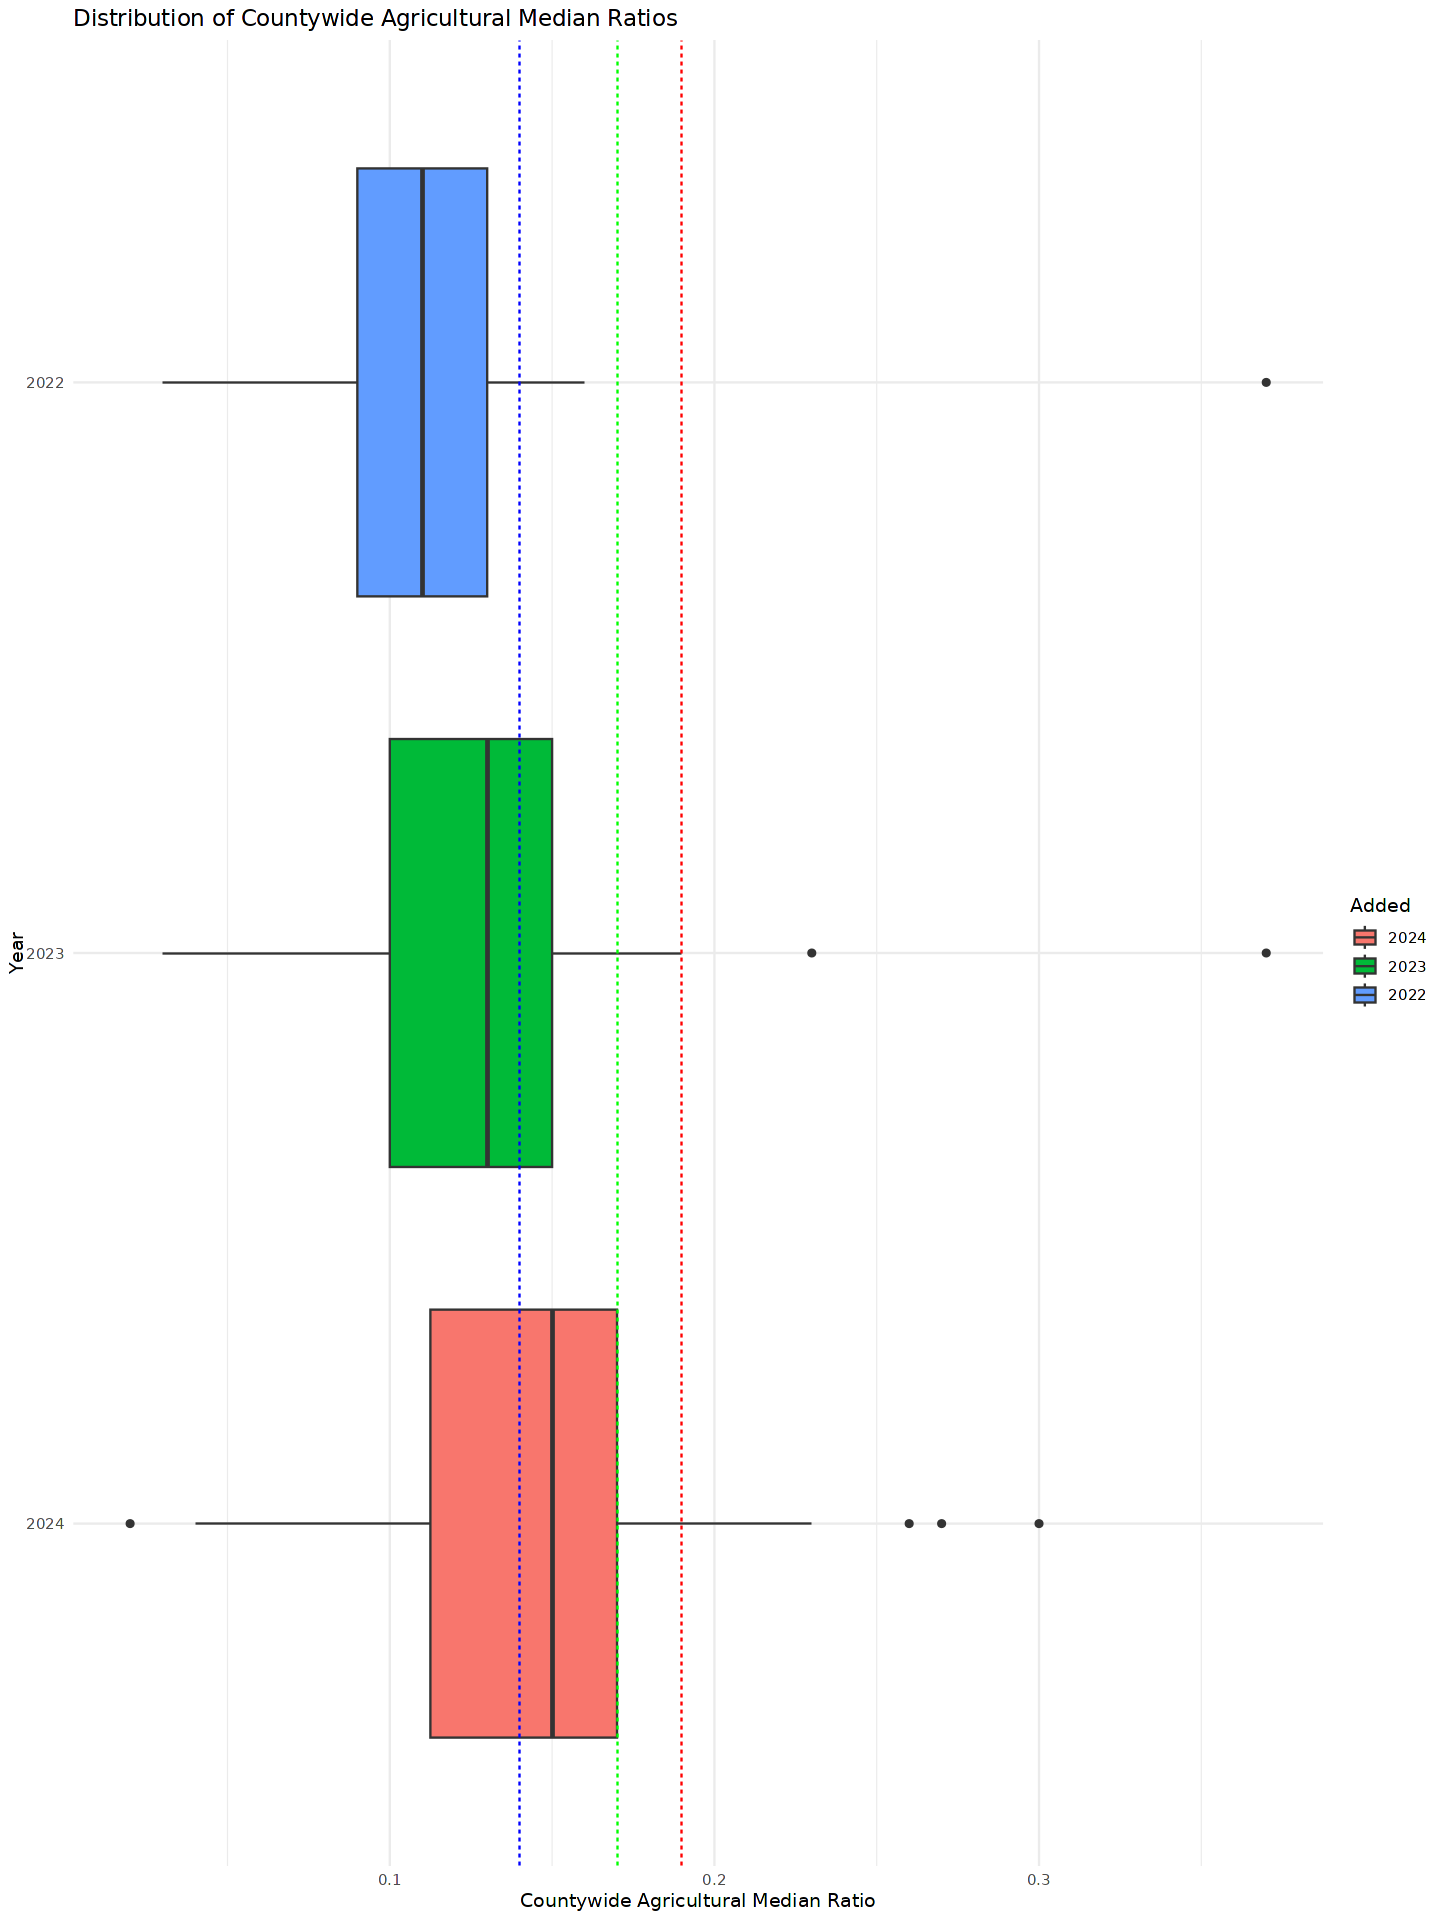

In [ ]:
# Plots countywide Ag median ratios for 2022, 2023, and 2024
options(repr.plot.width = 12, repr.plot.height = 16)
cresults$Added <- factor(cresults$Added, levels = c("2024", "2023", "2022"))
head(cresults)

ggplot(cresults, aes(x = Added, y = Median,fill=Added)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Distribution of Countywide Agricultural Median Ratios",
       x = "Year",
       y = "Countywide Agricultural Median Ratio") +
  geom_hline(yintercept = 0.14,linetype = 'dashed',color='blue') +
  geom_hline(yintercept = 0.17,linetype = 'dashed',color='green') +
  geom_hline(yintercept = 0.19,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

Warning message:
"Removed 52 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


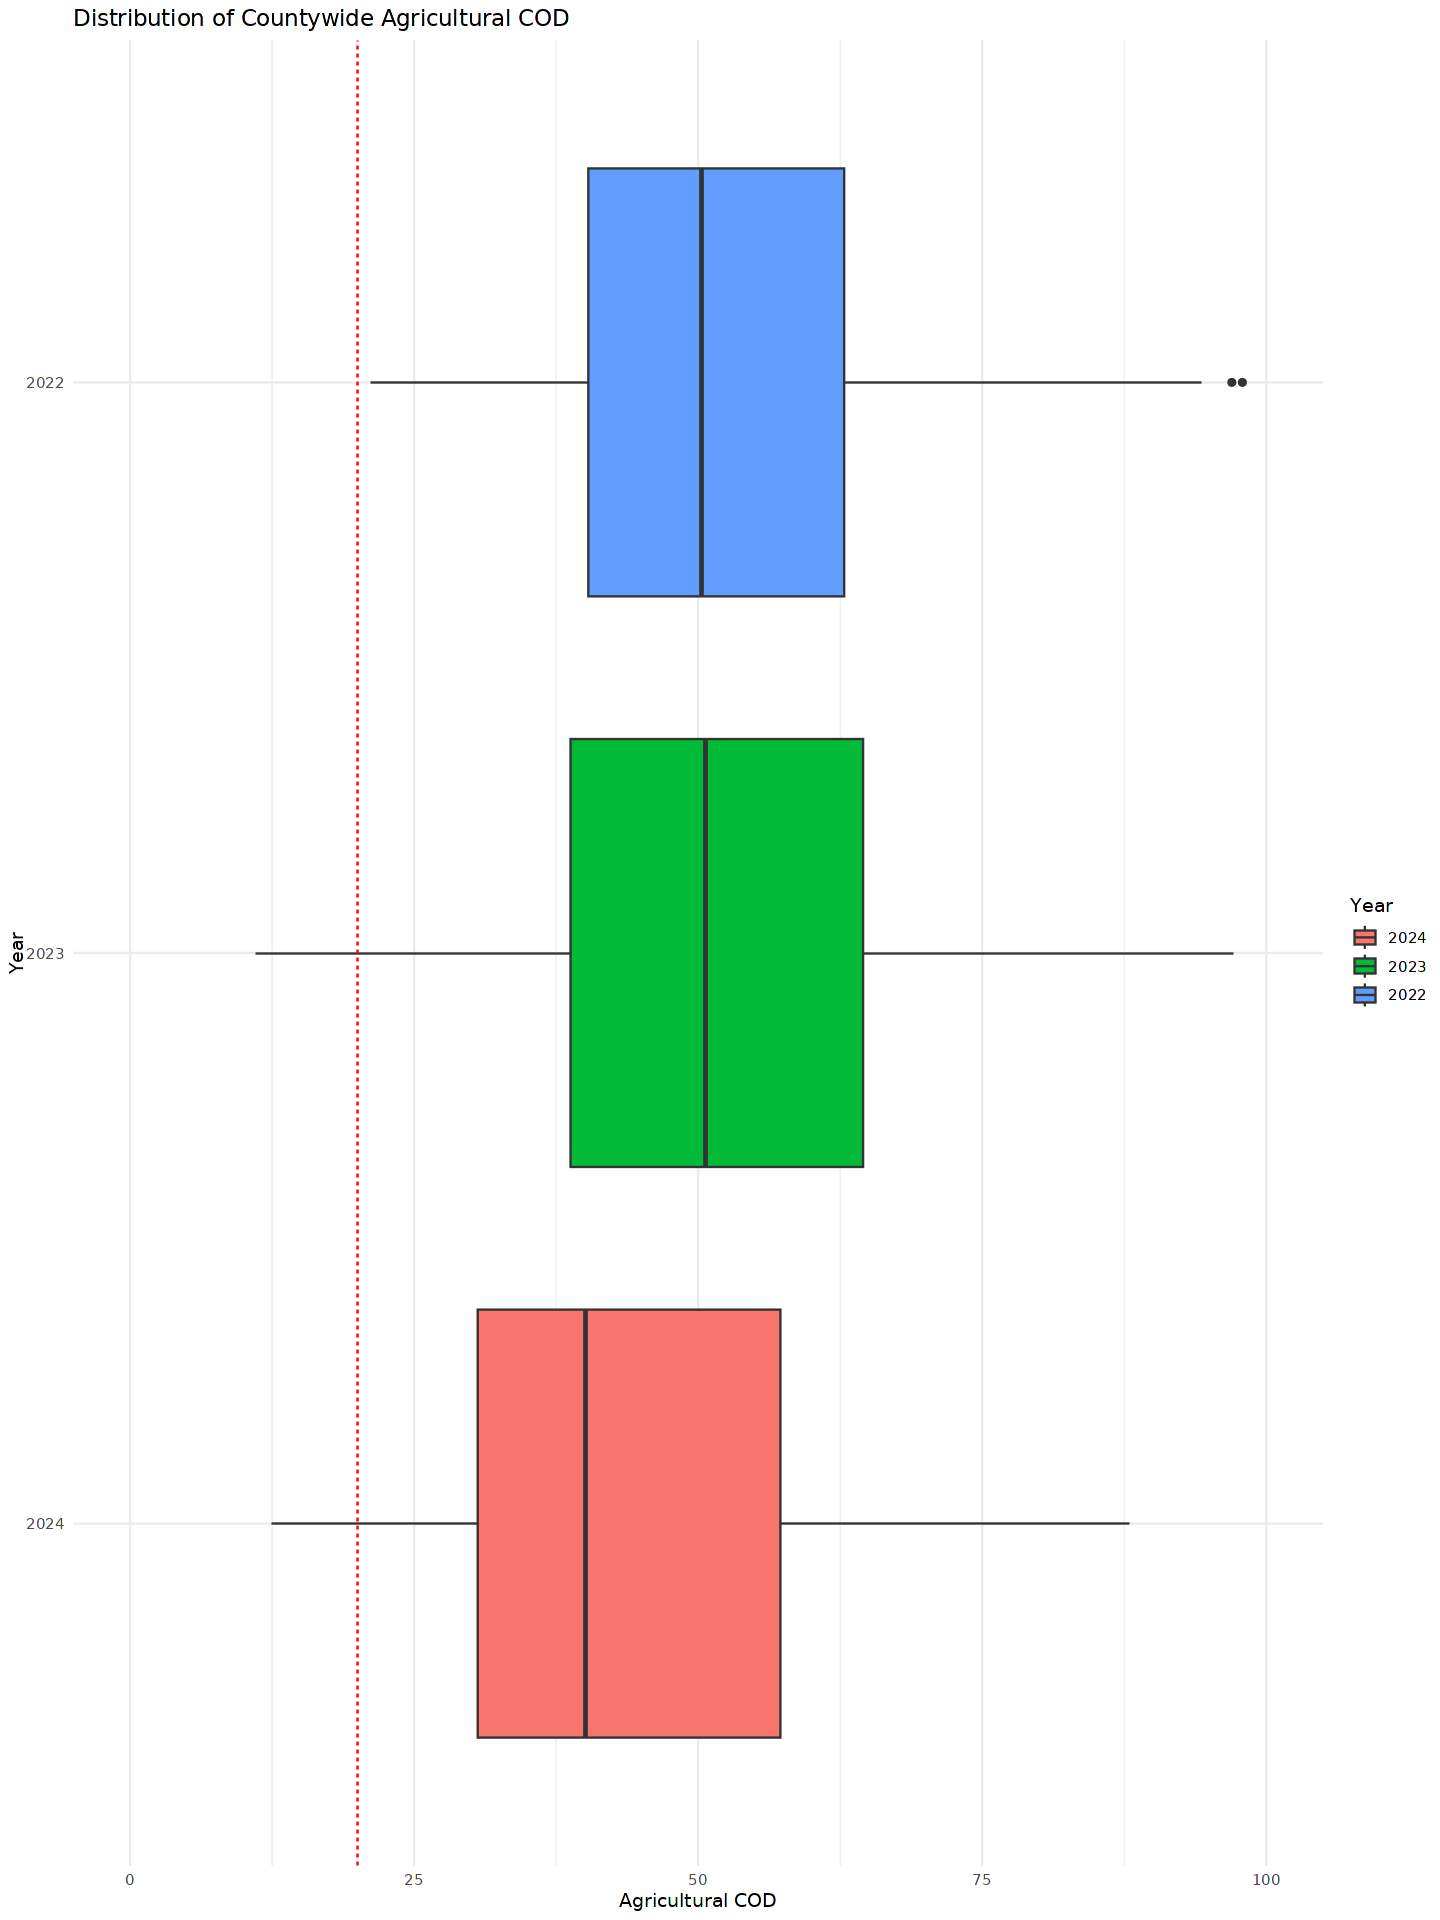

In [ ]:
# Plots countywide Ag COD for 2022, 2023, and 2024
ggplot(cresults, aes(x = Added, y = COD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0,100) +
  labs(title = "Distribution of Countywide Agricultural COD",
       x = "Year",
       y = "Agricultural COD",
       fill = "Year") +
geom_hline(yintercept = 20,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

Warning message:
"Removed 57 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


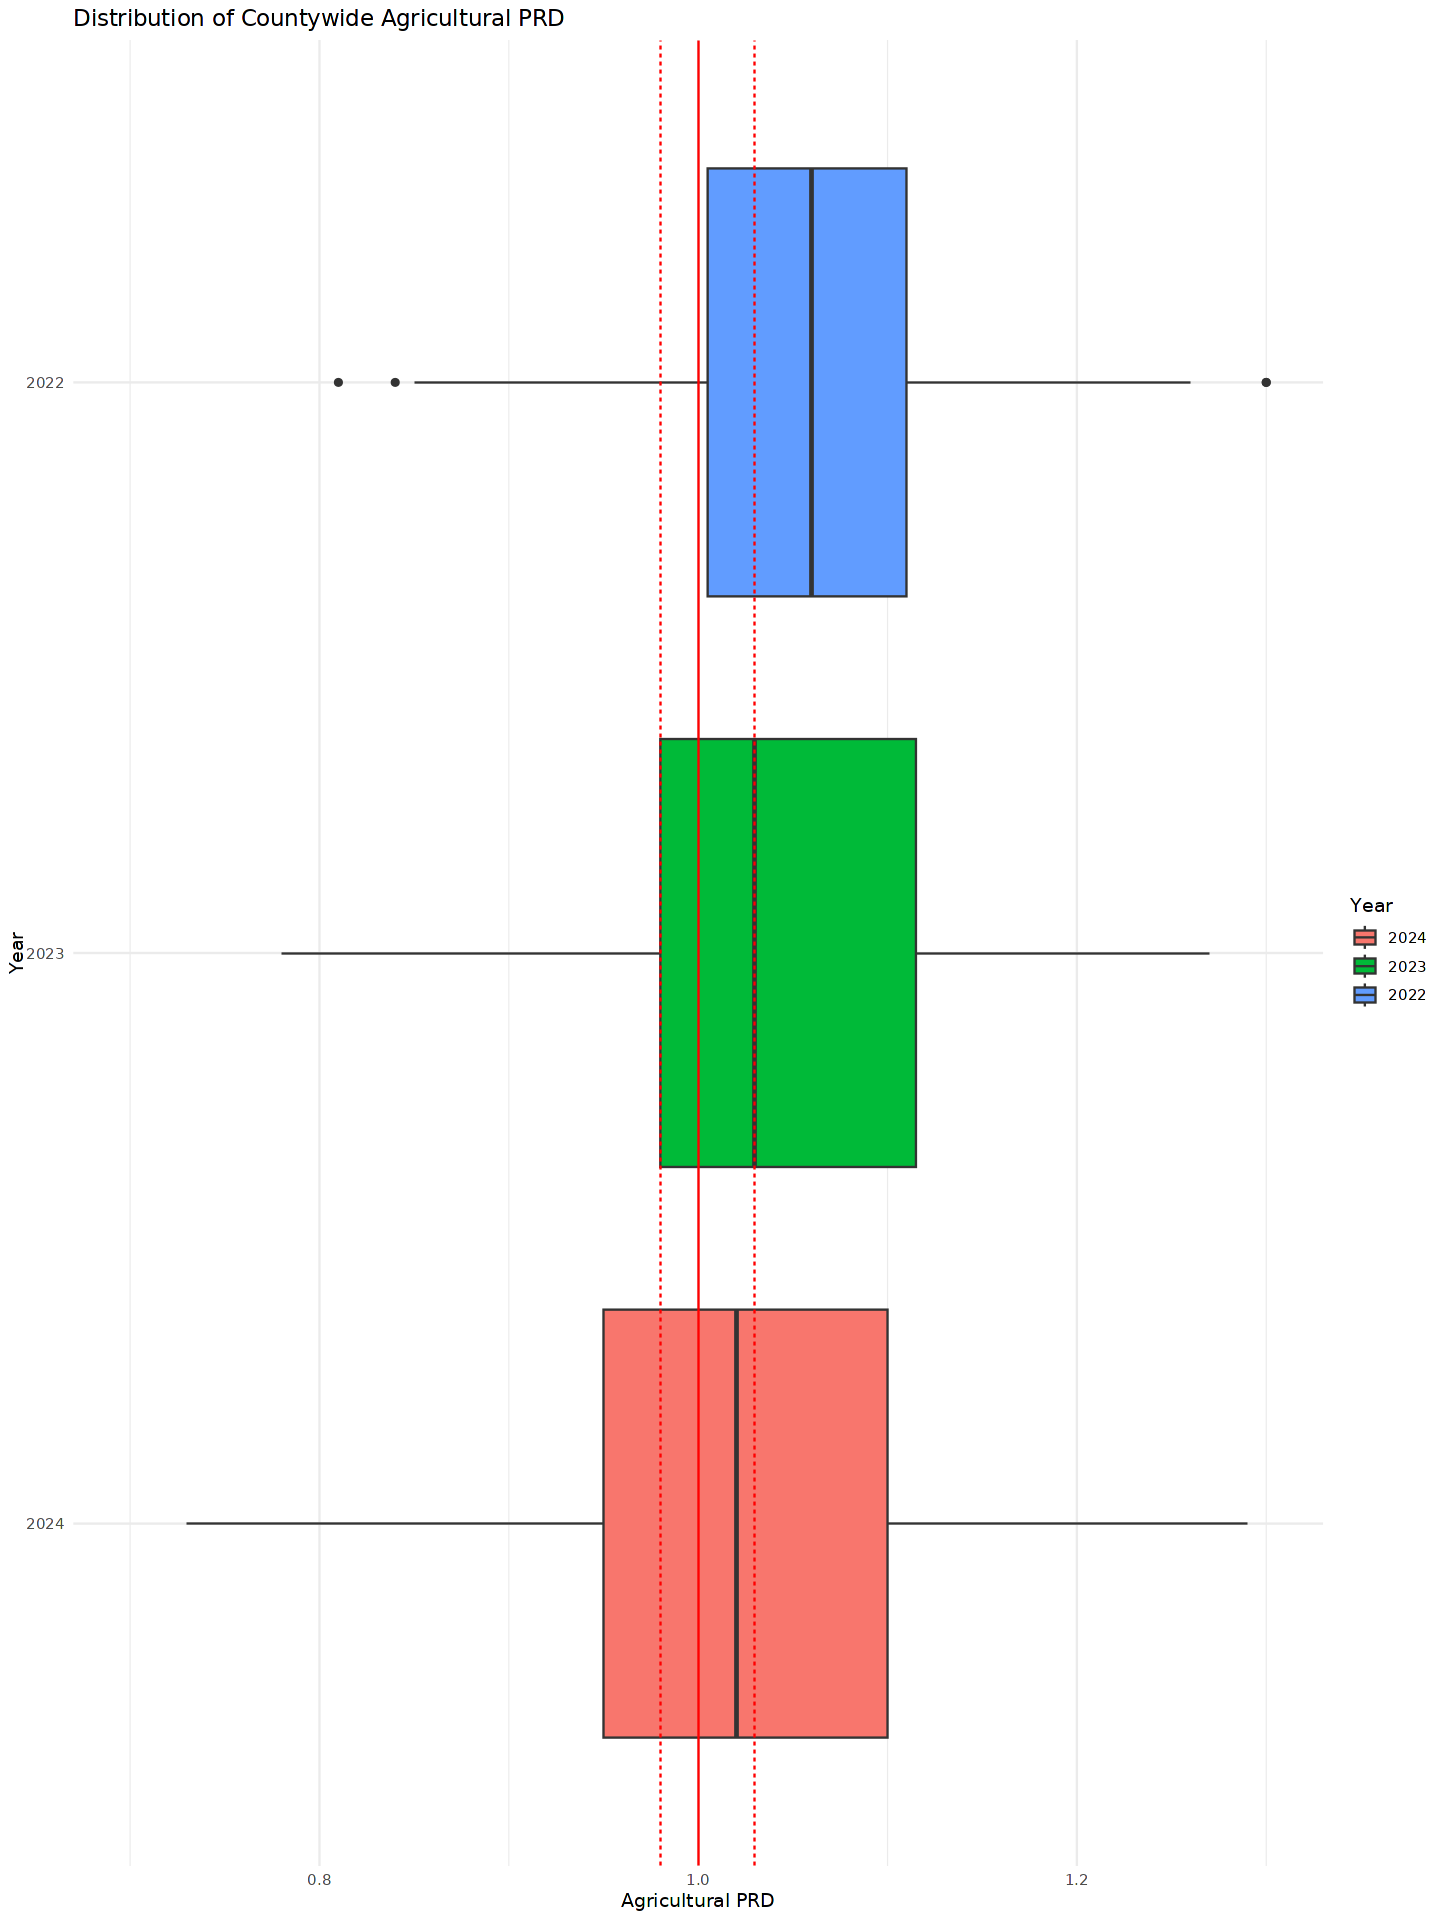

In [ ]:
# Plots countywide Ag PRD for 2022, 2023, and 2024
ggplot(cresults, aes(x = Added, y = PRD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0.7,1.3) + 
  labs(title = "Distribution of Countywide Agricultural PRD",
       x = "Year",
       y = "Agricultural PRD",
       fill = "Year") +
geom_hline(yintercept = 1,color='red') +
geom_hline(yintercept = 0.98,linetype = 'dashed',color='red') +
geom_hline(yintercept = 1.03,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

In [ ]:
# Combines Clustered Ratio Study Results for Original, Moderate, and Aggressive for plotting
ogresult = ratiostudyscript(mapping_list,'grouped_original')
agresult = ratiostudyscript(mapping_list,'grouped_aggressive')
modresult = ratiostudyscript(mapping_list,'grouped_moderate')
ogresult$Added = 'Original'
agresult$Added = 'Aggressive'
modresult$Added = 'Moderate'
cresults = rbind(ogresult,modresult,agresult)

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,,Industrial Vacant,3,NA,NA,NA,NA,NA,NA,NA,0,Original
df_sp,"Allen, Blackford, Delaware, Wells",Industrial Improved,3,0.72000,0.82,1.00,10.20,13.52,1.02,0,5,Original
11,"Allen, Delaware",Commercial Vacant,3,NA,NA,NA,NA,NA,NA,NA,0,Original
2.5%,"Adams, Blackford, Delaware, Grant, Henry, Howard, Huntington, Jay, Tipton, Wabash, Wells",Commercial Improved,3,0.88975,0.95,0.98,22.28,76.03,1.07,0,110,Original
2.5%1,"Adams, Allen, Blackford, Delaware, Henry, Howard, Huntington, Tipton, Wayne, Wells",Residential Vacant,3,0.94000,0.98,1.00,17.07,27.69,0.95,0,58,Original
2.5%2,"Adams, Henry, Howard, Huntington, Jay, Randolph, Wells, Allen, Blackford, Delaware, Grant, Hamilton, Madison, Miami, Tipton, Wabash, Wayne",Residential Improved,3,0.95000,0.96,0.96,13.76,40.38,1.03,0,4729,Original


Warning message:
"Removed 28 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


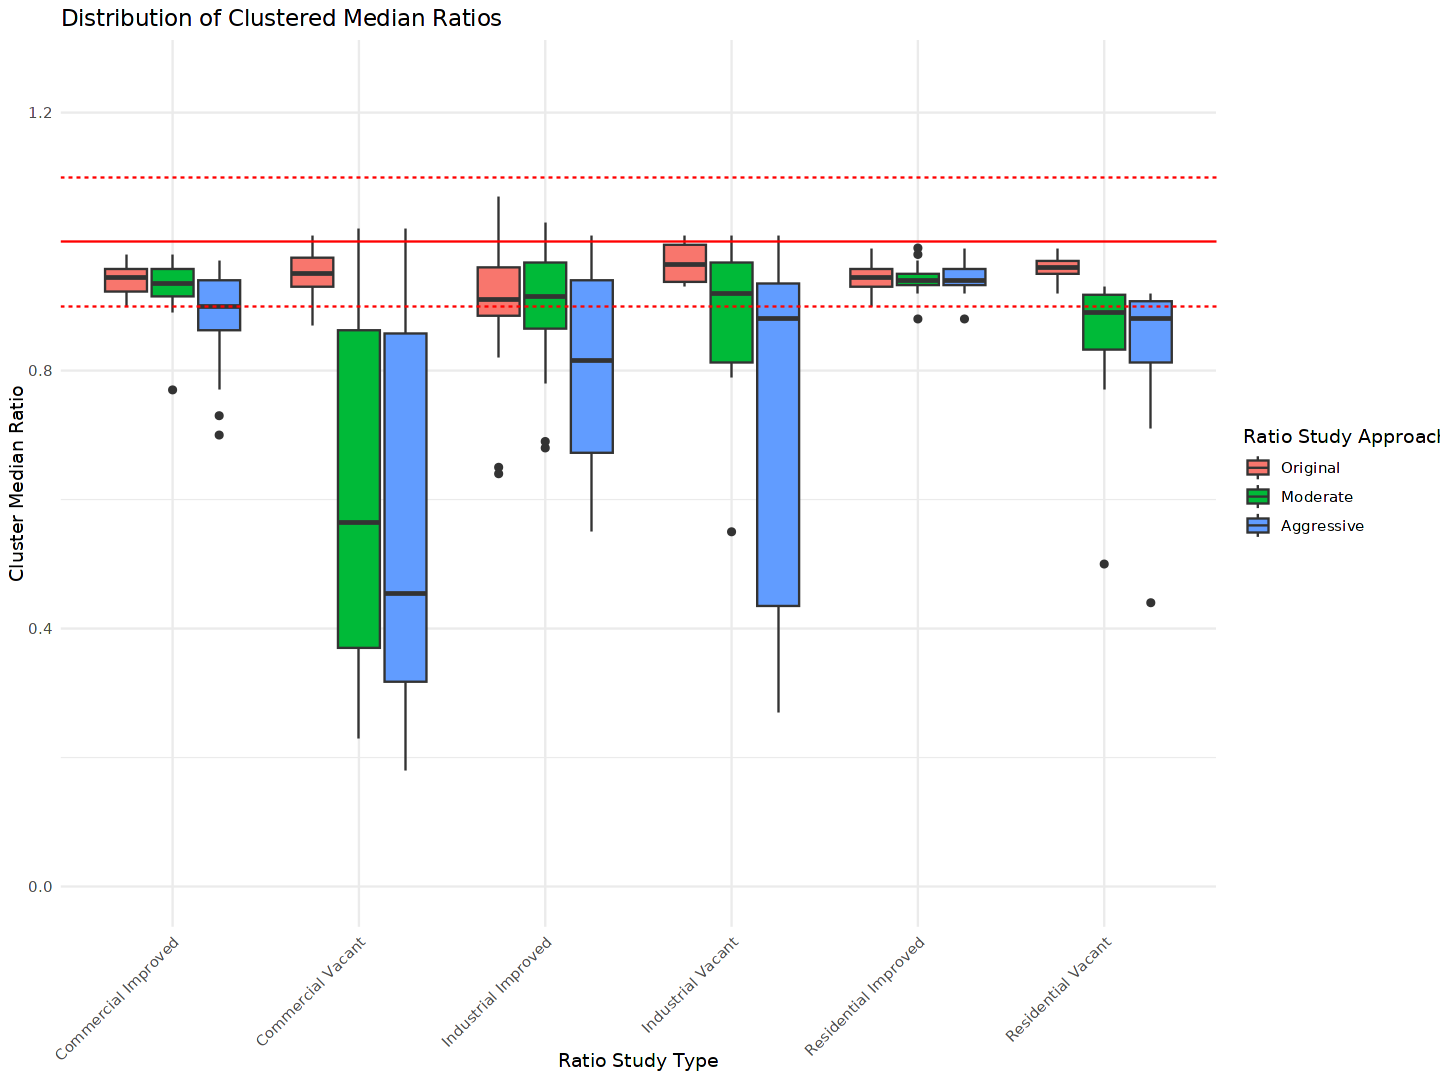

In [ ]:
# Plots clustered median ratios for Original, Moderate, and Aggressive
options(repr.plot.width = 12, repr.plot.height = 9)  # Set width and height in inches
cresults$Added <- factor(cresults$Added, levels = c("Original", "Moderate", "Aggressive"))
head(cresults)

ggplot(cresults, aes(x = Type, y = Median, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Distribution of Clustered Median Ratios",
       x = "Ratio Study Type",
       y = "Cluster Median Ratio",
       fill = "Ratio Study Approach") +
  geom_hline(yintercept = 1,color='red') +
  geom_hline(yintercept = 0.9,linetype = 'dashed',color='red') +
  geom_hline(yintercept = 1.1,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ylim(0,1.25) #+
  #coord_flip()

Warning message:
"Removed 35 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


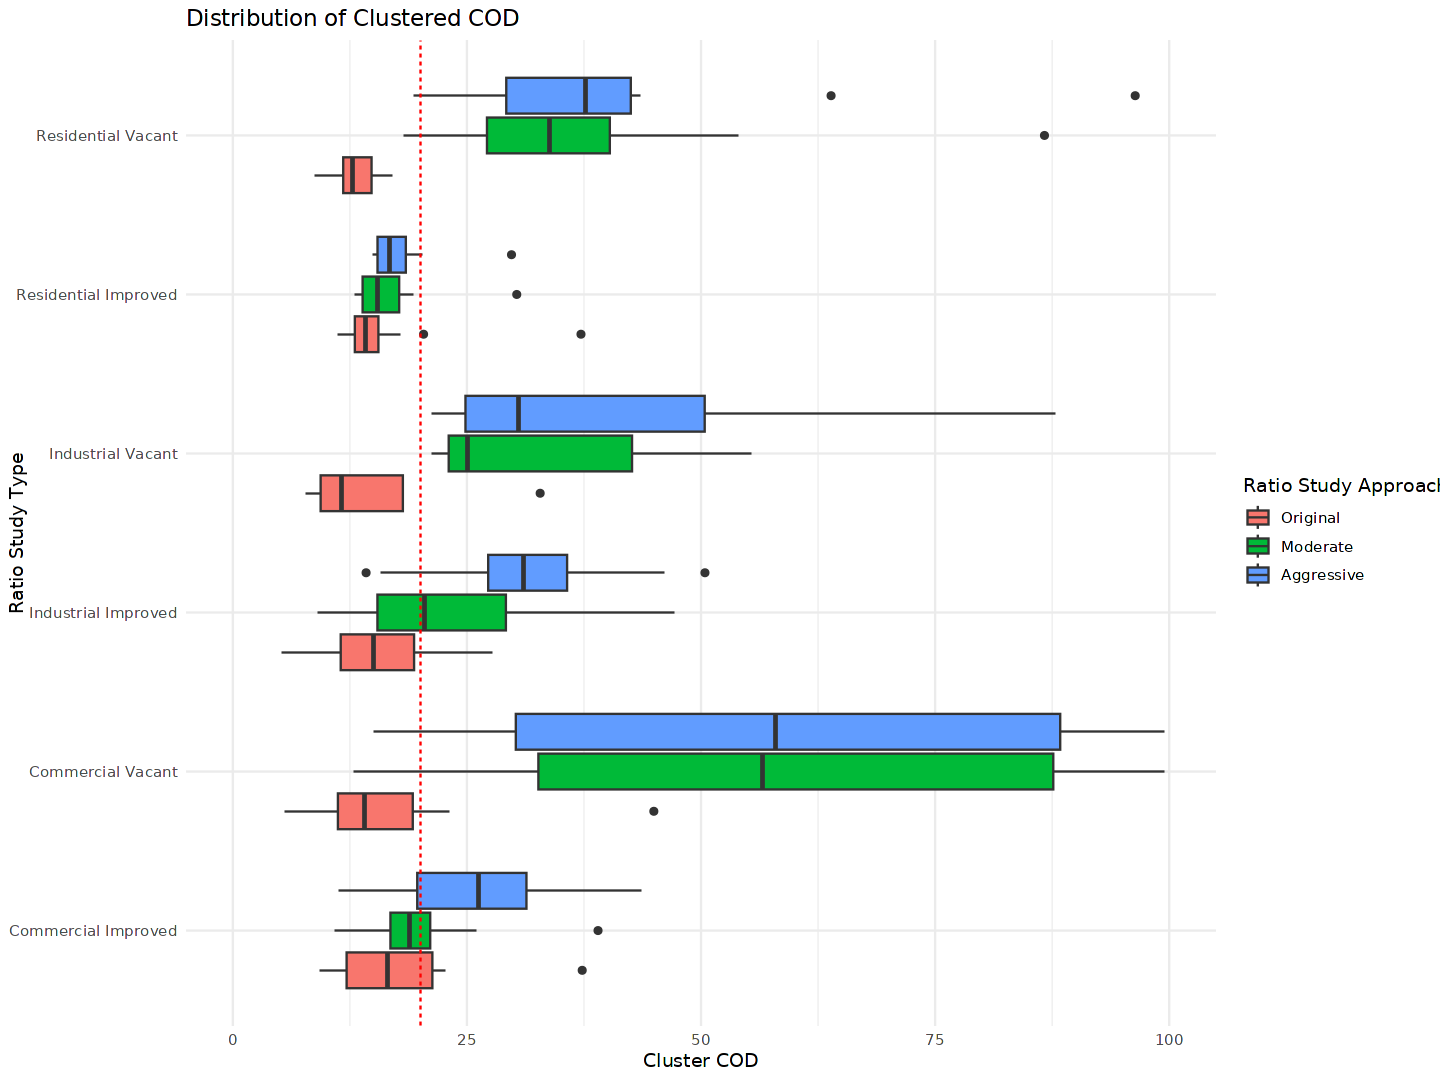

In [ ]:
# Plots clustered COD for Original, Moderate, and Aggressive
ggplot(cresults, aes(x = Type, y = COD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0,100) +
  labs(title = "Distribution of Clustered COD",
       x = "Ratio Study Type",
       y = "Cluster COD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 20,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

Warning message:
"Removed 65 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


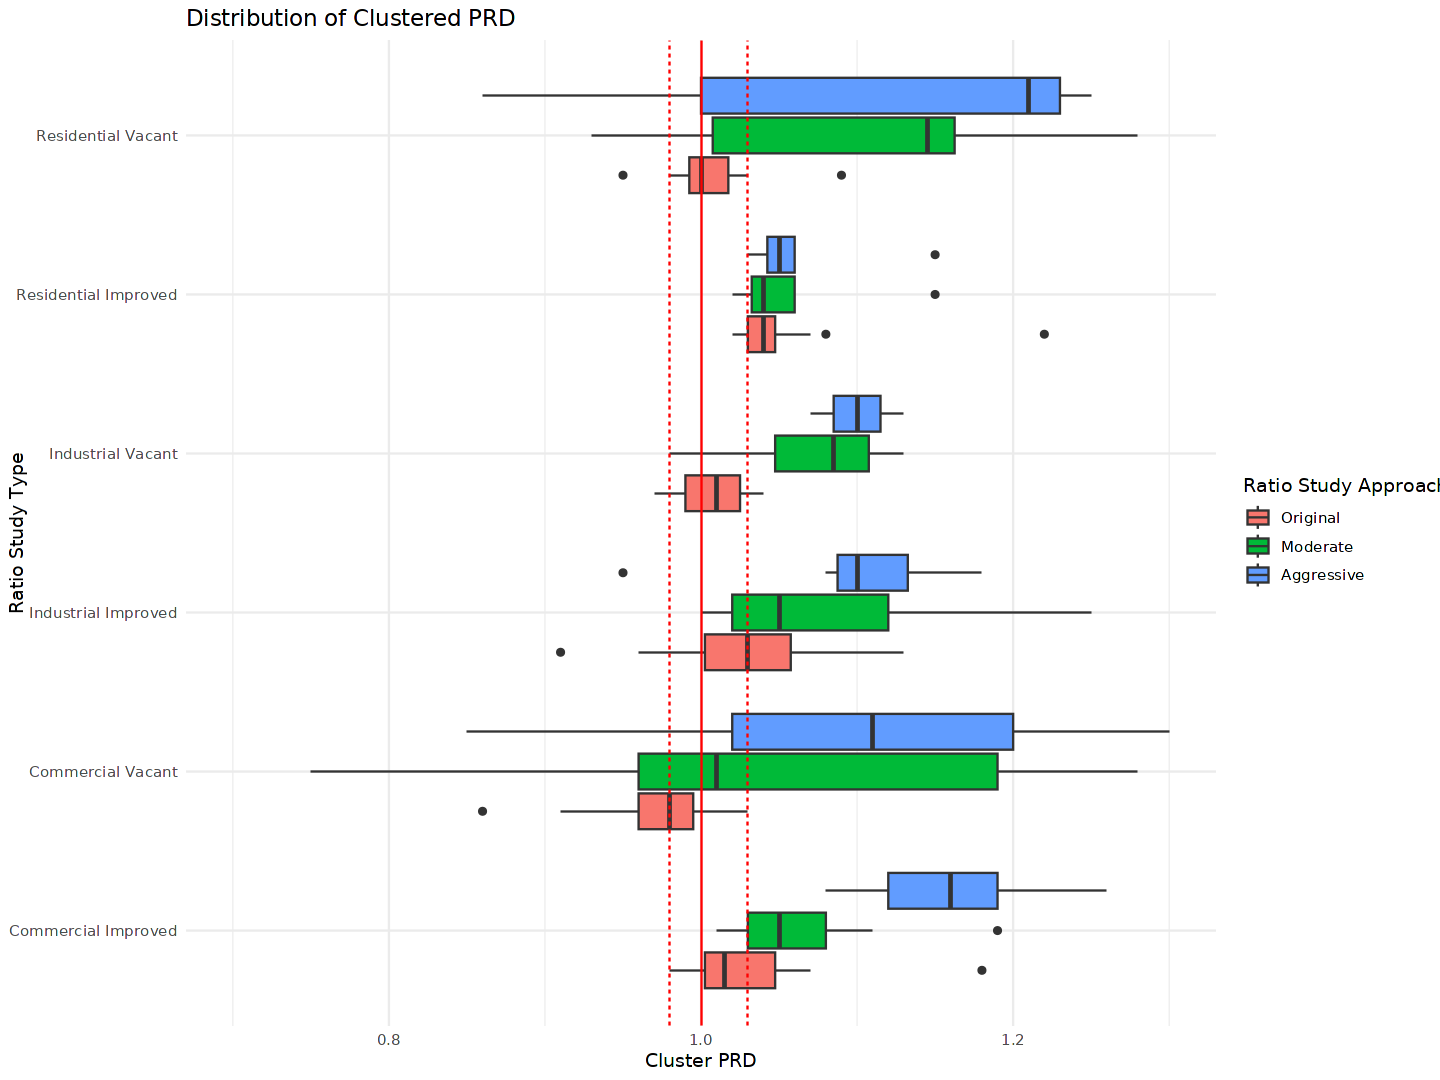

In [ ]:
# Plots Clustered PRD for Original, Moderate, and Aggressive
ggplot(cresults, aes(x = Type, y = PRD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0.7,1.3) + 
  labs(title = "Distribution of Clustered PRD",
       x = "Ratio Study Type",
       y = "Cluster PRD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 1,color='red') +
geom_hline(yintercept = 0.98,linetype = 'dashed',color='red') +
geom_hline(yintercept = 1.03,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added,Sales_og,AddedSales
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
2,"Tipton, Madison, Jay, Huntington, Wabash, Wells, Allen, Delaware",Commercial Vacant,3,0.25,0.36,0.91,92.91,76.69,0.75,0,12,Moderate,0,1200.00000
7,"Noble, Whitley, Steuben, Kosciusko",Commercial Vacant,1,0.21,0.31,0.70,86.51,76.55,1.43,0,13,Moderate,0,1300.00000
13,"Henry, Ripley, Jefferson, Fayette, Jennings, Scott, Jackson, Switzerland, Washington, Decatur",Commercial Vacant,7,0.96,1.02,1.02,27.81,50.82,1.19,0,30,Moderate,14,106.66667
18,"Pulaski, Fountain, Jasper",Commercial Vacant,5,0.22,0.51,0.98,69.21,68.69,0.63,0,10,Moderate,6,57.14286
22,"Parke, Hamilton, Montgomery, Boone, Hendricks, Vigo, Morgan, Clay, Putnam, Greene",Commercial Vacant,2,0.32,0.62,0.79,56.55,68.02,1.10,0,41,Moderate,16,147.05882
27,"Cass, Carroll, Marshall, Starke",Commercial Vacant,6,0.37,0.72,0.98,43.20,54.28,1.25,0,17,Moderate,13,28.57143


Warning message:
"Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


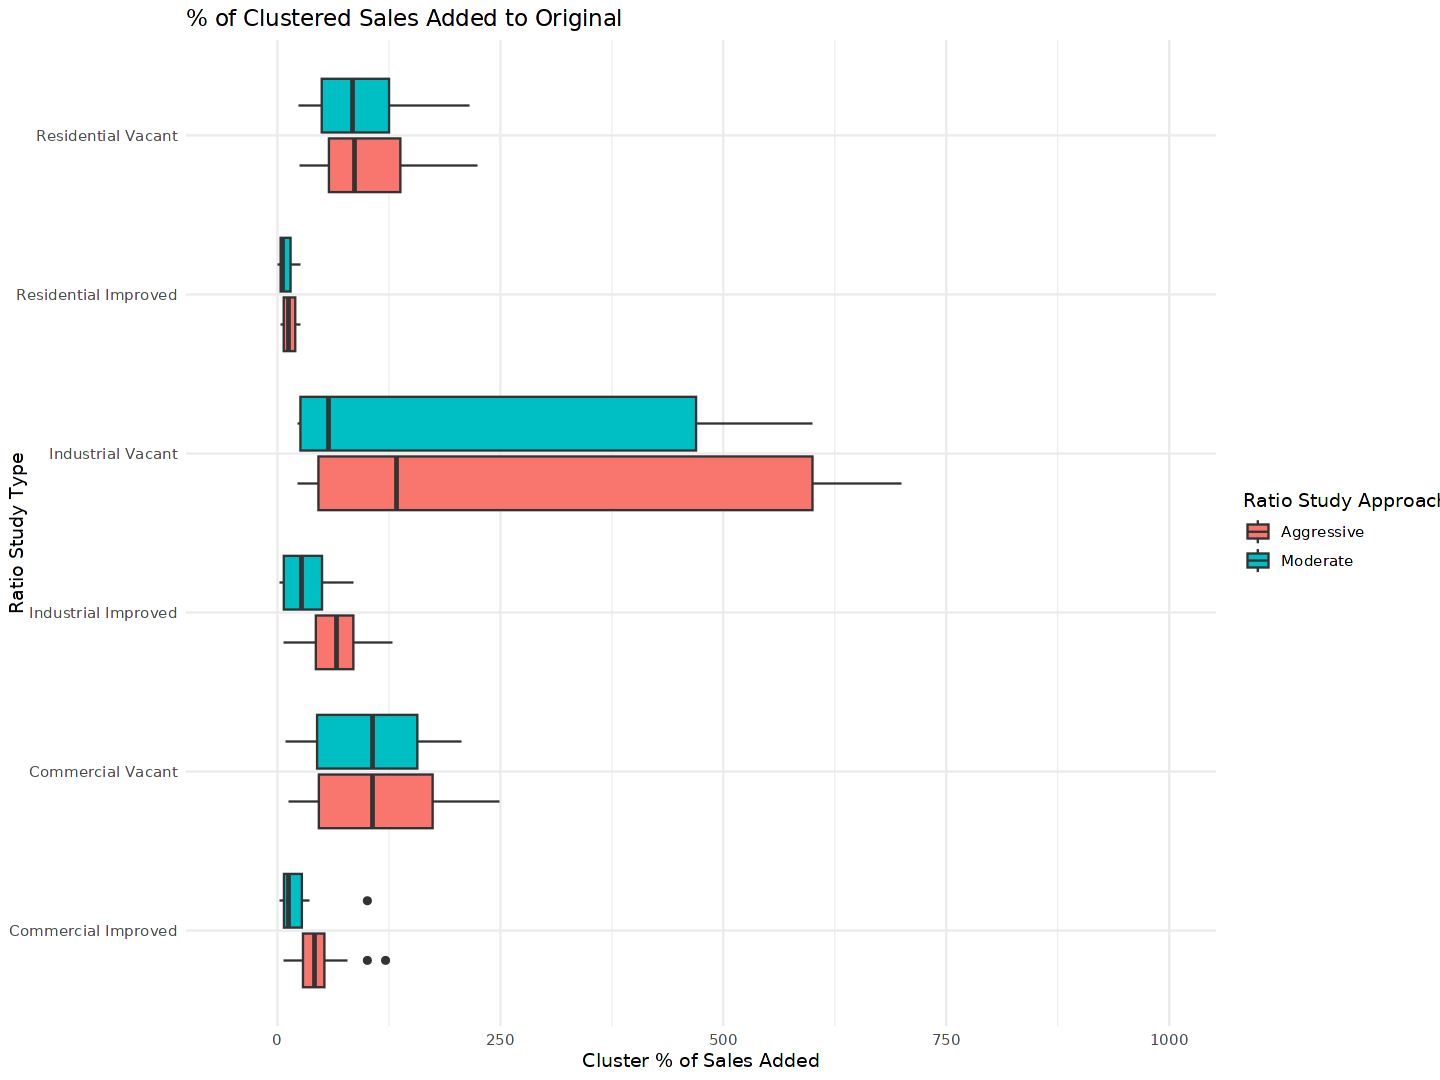

In [ ]:
# Plots Clustered % of Sales Added to Original for Aggressive and Moderate
library(dplyr)

# Filter added rows and original rows
cresultsadd <- cresults %>% filter(Added != "Original")
cresultsog  <- cresults %>% filter(Added == "Original")

# Join the original rows to the added rows by County and Type
cresultsadd <- cresultsadd %>%
  left_join(cresultsog %>% select(Grouping, Type, Sales), by = c("Grouping", "Type"), suffix = c("", "_og")) %>%
  mutate(AddedSales = (Sales - Sales_og) / (Sales_og + 1) * 100) %>%
  filter(AddedSales != 0)

# Set factor order
cresultsadd$Added <- factor(cresultsadd$Added, levels = c("Aggressive", "Moderate", "Original"))
head(cresultsadd[cresultsadd$Type == 'Commercial Vacant',])
# Plot
ggplot(cresultsadd, aes(x = Type, y = AddedSales, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  ylim(-50, 1000) +  # better than `ylim()` to preserve outliers
  labs(
    title = "% of Clustered Sales Added to Original",
    x = "Ratio Study Type",
    y = "Cluster % of Sales Added",
    fill = "Ratio Study Approach"
  ) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

In [ ]:
# Combines Countywide Ratio Study Results for Original, Moderate, and Aggressive for plotting
ogresult = ratiostudyscript(mapping_list,'original')
agresult = ratiostudyscript(mapping_list,'aggressive')
modresult = ratiostudyscript(mapping_list,'moderate')
ogresult = ogresult[ogresult$Grouping == 'Countywide',]
agresult = agresult[agresult$Grouping == 'Countywide',]
modresult = modresult[modresult$Grouping == 'Countywide',]
ogresult$Added = 'Original'
agresult$Added = 'Aggressive'
modresult$Added = 'Moderate'
cresults = rbind(ogresult,modresult,agresult)

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,Adams,Industrial Vacant,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
2,Adams,Industrial Improved,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
3,Adams,Commercial Vacant,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
2.5%,Adams,Commercial Improved,Countywide,0.85,0.95,1.05,13.46,15.30,1.02,0,26,Original
df_sp,Adams,Residential Vacant,Countywide,0.74,0.95,1.24,19.40,23.85,1.01,0,5,Original
2.5%1,Adams,Residential Improved,Countywide,0.93,0.95,0.96,13.49,17.48,1.02,0,679,Original


Warning message:
"Removed 773 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


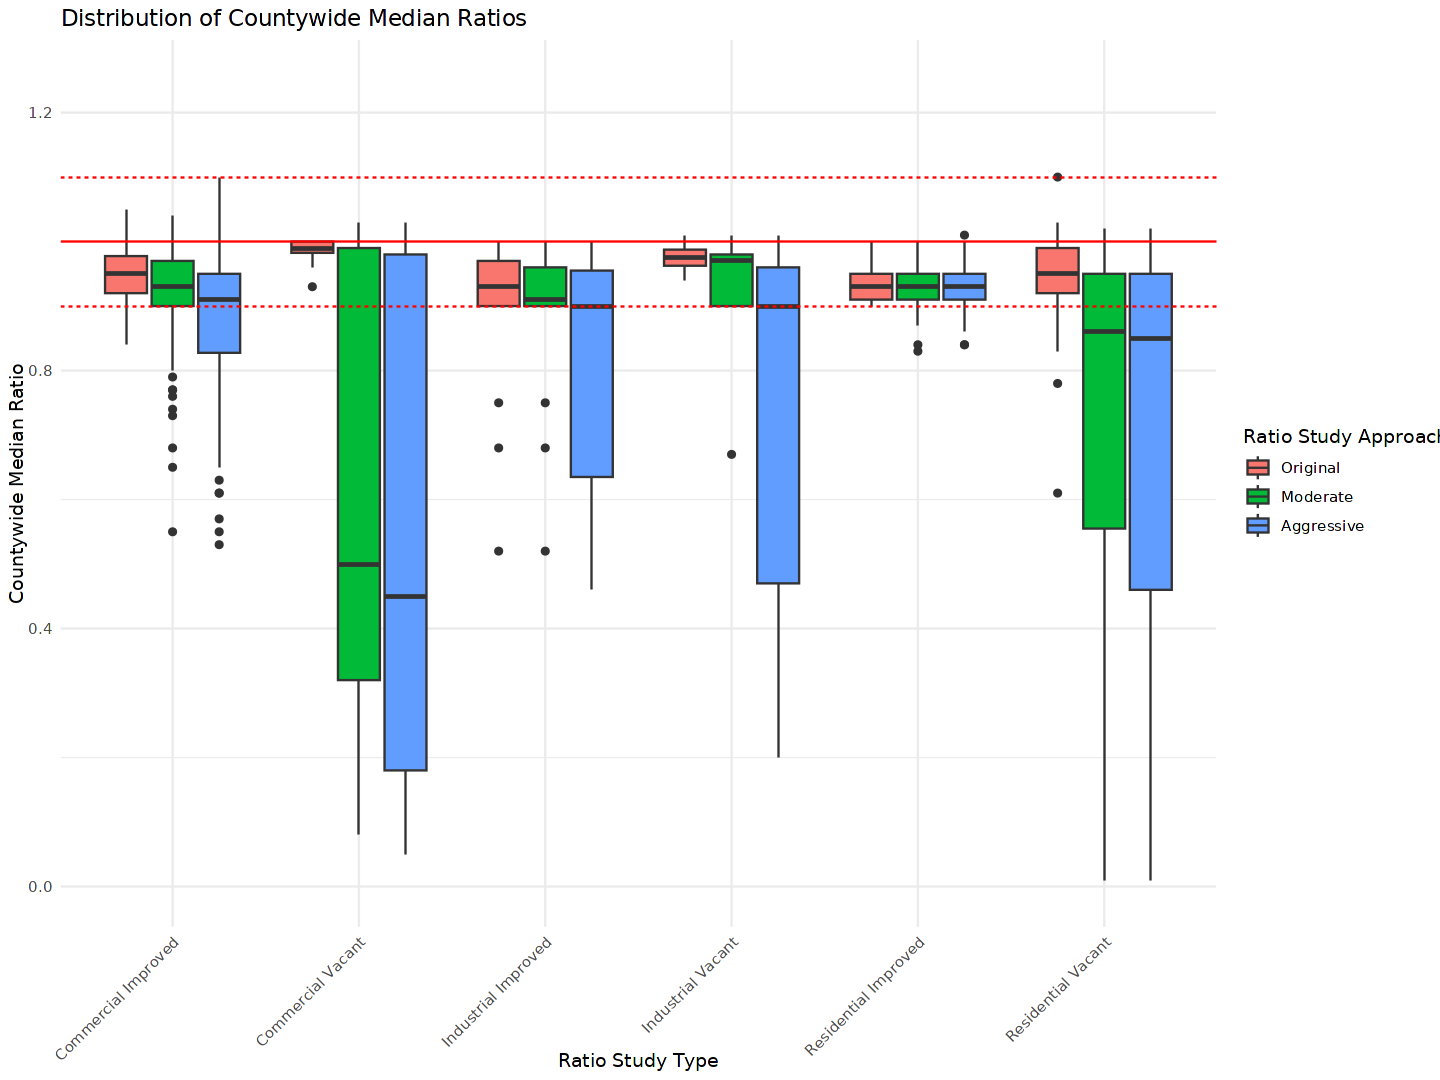

In [ ]:
# Plots countywide median ratios for Original, Moderate, and Aggressive
options(repr.plot.width = 12, repr.plot.height = 9)
cresults$Added <- factor(cresults$Added, levels = c("Original", "Moderate", "Aggressive"))
head(cresults)

ggplot(cresults, aes(x = Type, y = Median, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Distribution of Countywide Median Ratios",
       x = "Ratio Study Type",
       y = "Countywide Median Ratio",
       fill = "Ratio Study Approach") +
  geom_hline(yintercept = 1,color='red') +
  geom_hline(yintercept = 0.9,linetype = 'dashed',color='red') +
  geom_hline(yintercept = 1.1,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ylim(0,1.25) #+
  #coord_flip()

Warning message:
"Removed 822 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


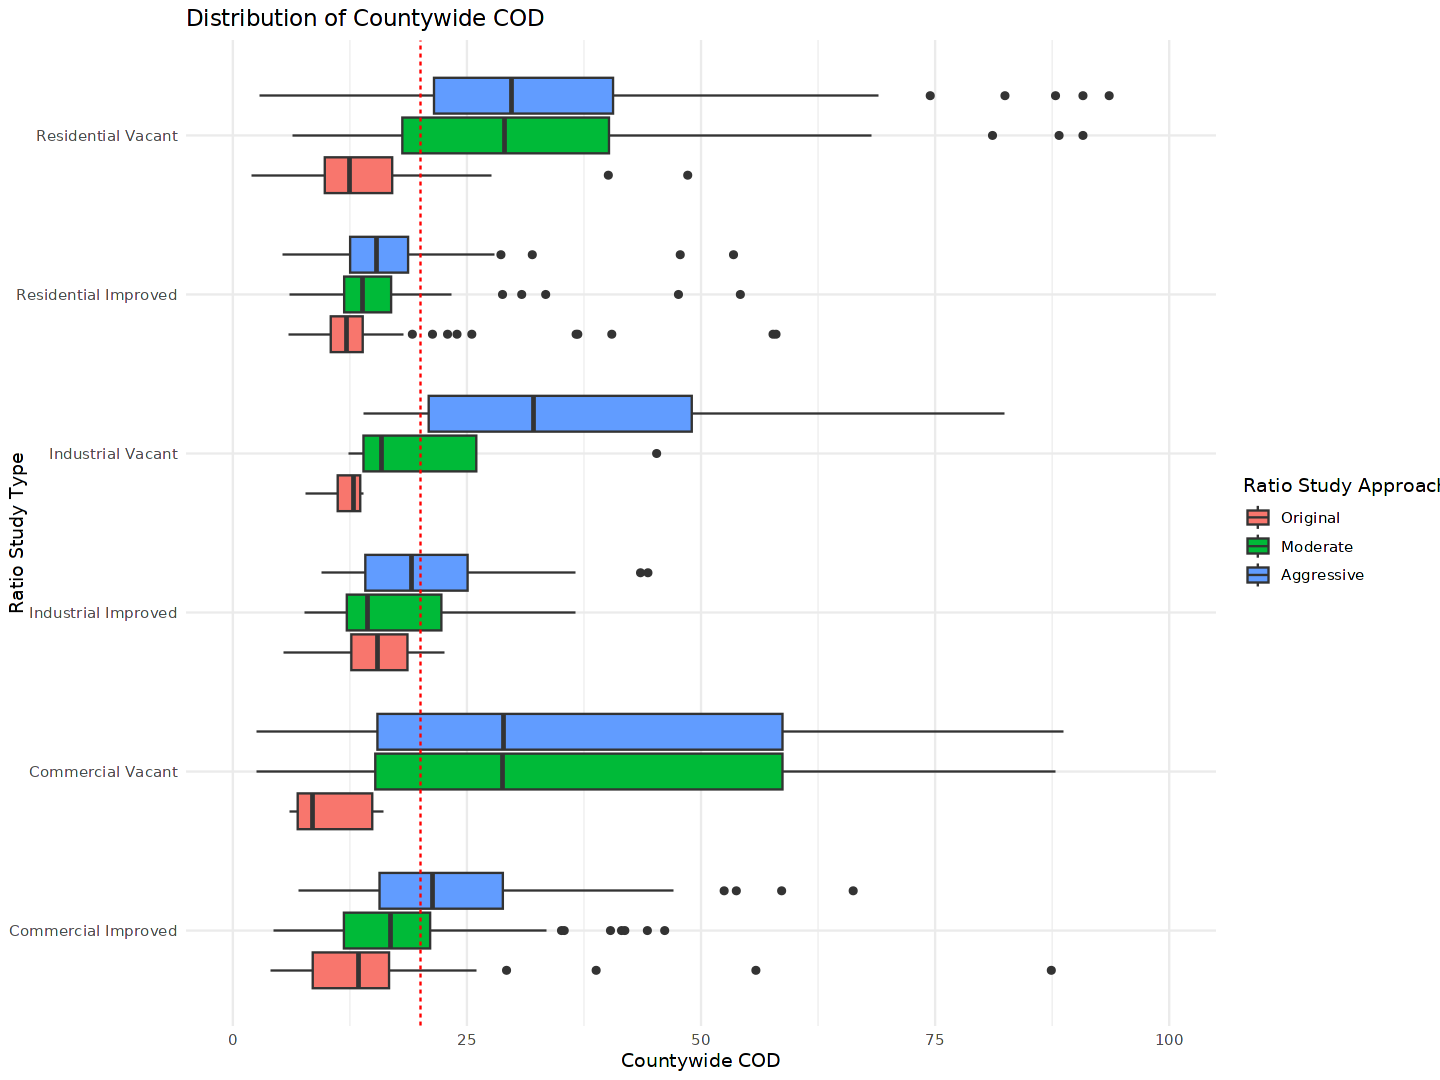

In [ ]:
# Plots countywide COD for Original, Moderate, and Aggressive
ggplot(cresults, aes(x = Type, y = COD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0,100) +
  labs(title = "Distribution of Countywide COD",
       x = "Ratio Study Type",
       y = "Countywide COD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 20,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()


Warning message:
"Removed 891 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


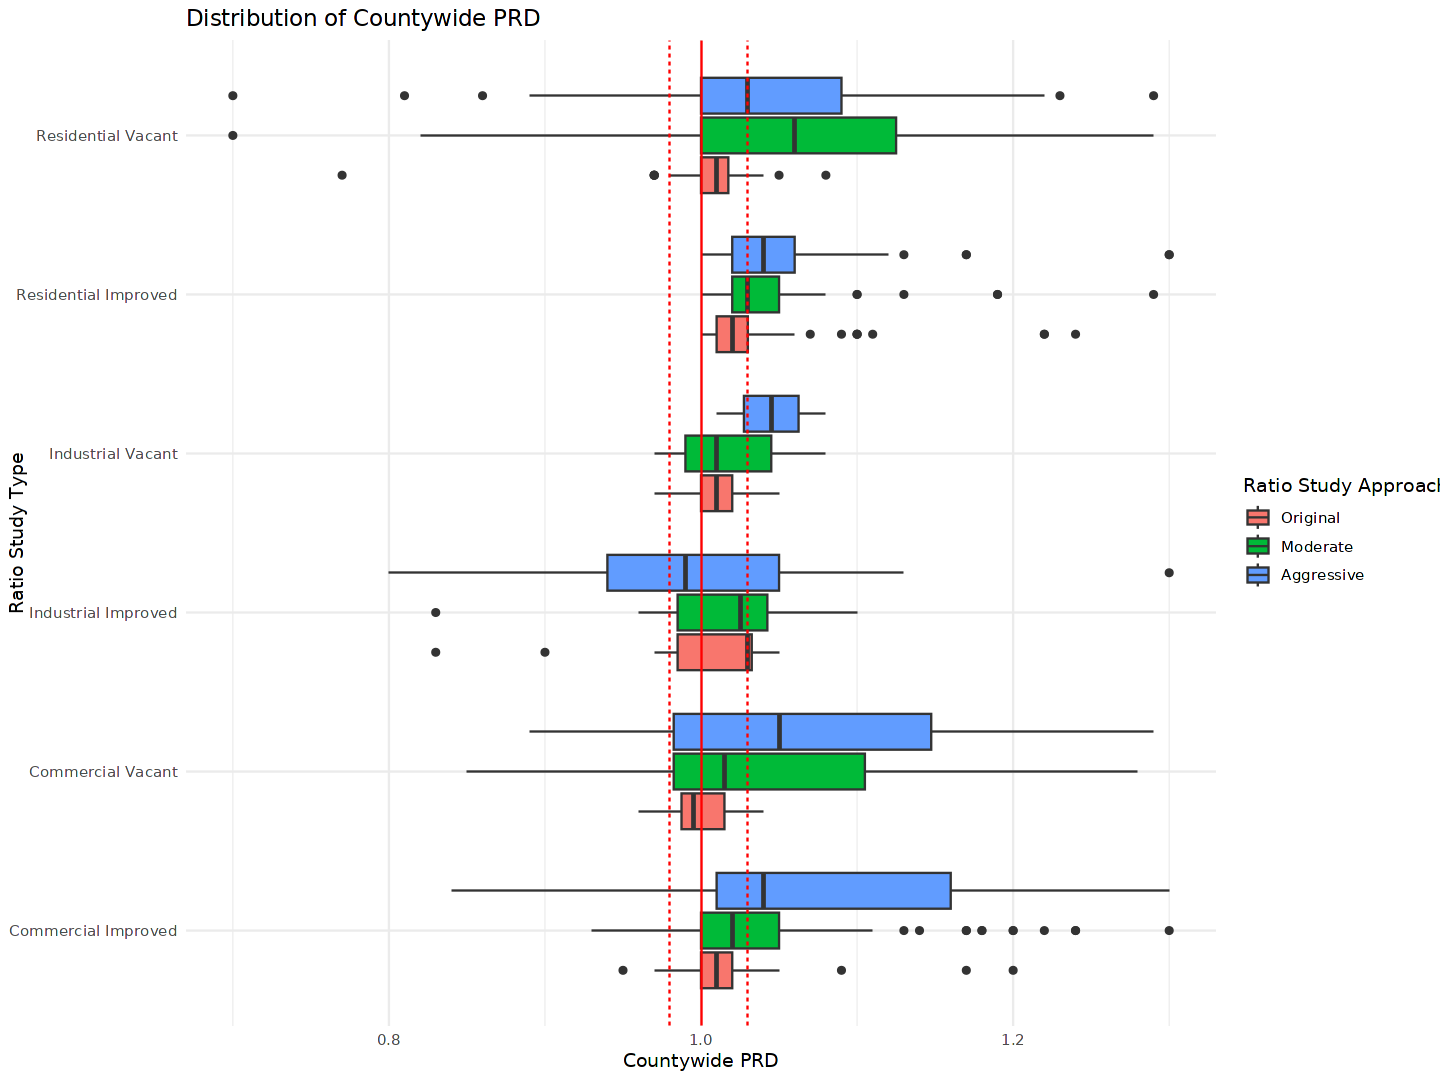

In [ ]:
# Plots Countywide PRD for Original, Moderate, and Aggressive
ggplot(cresults, aes(x = Type, y = PRD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0.7,1.3) + 
  labs(title = "Distribution of Countywide PRD",
       x = "Ratio Study Type",
       y = "Countywide PRD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 1,color='red') +
geom_hline(yintercept = 0.98,linetype = 'dashed',color='red') +
geom_hline(yintercept = 1.03,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added,Sales_og,AddedSales
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
14,Boone,Commercial Vacant,Countywide,0.17,0.63,1.00,55.75,71.15,1.19,0,7,Moderate,0,700.0000
25,Cass,Commercial Vacant,Countywide,0.29,0.46,0.72,127.78,128.98,1.59,0,6,Moderate,0,600.0000
29,Clark,Commercial Vacant,Countywide,0.06,0.14,1.90,281.48,158.10,1.67,0,5,Moderate,0,500.0000
58,Fayette,Commercial Vacant,Countywide,0.39,1.02,1.71,28.80,46.86,1.11,0,5,Moderate,0,500.0000
76,Hamilton,Commercial Vacant,Countywide,0.05,0.09,0.32,361.18,118.03,1.07,0,52,Moderate,16,211.7647
80,Hancock,Commercial Vacant,Countywide,0.23,0.37,0.85,58.70,58.42,1.22,0,5,Moderate,0,500.0000


Warning message:
"Removed 34 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


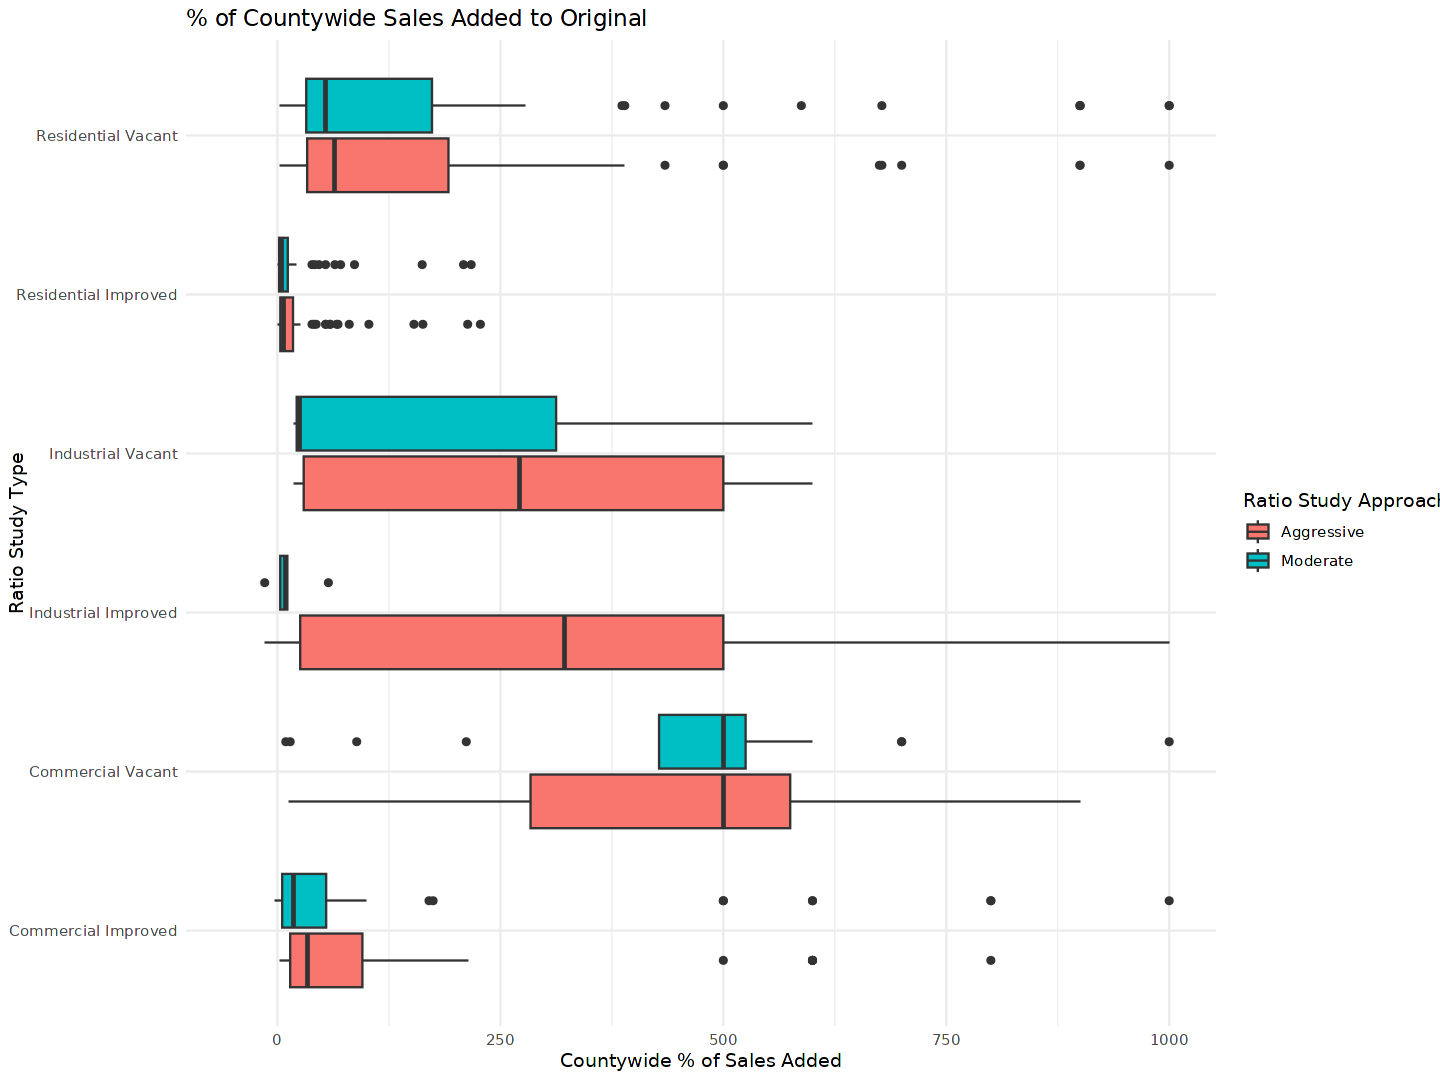

In [ ]:
# Plots Countywide % of Sales Added to Original for Aggressive and Moderate
cresultsadd <- cresults %>% filter(Added != "Original")
cresultsog  <- cresults %>% filter(Added == "Original")

cresultsadd <- cresultsadd %>%
  left_join(cresultsog %>% select(County, Type, Sales), by = c("County", "Type"), suffix = c("", "_og")) %>%
  mutate(AddedSales = (Sales - Sales_og) / (Sales_og + 1) * 100) %>%
  filter(AddedSales != 0)

# Set factor order
cresultsadd$Added <- factor(cresultsadd$Added, levels = c("Aggressive", "Moderate", "Original"))
head(cresultsadd[cresultsadd$Type == 'Commercial Vacant',])
# Plot
ggplot(cresultsadd, aes(x = Type, y = AddedSales, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  ylim(-50, 1000) + 
  labs(
    title = "% of Countywide Sales Added to Original",
    x = "Ratio Study Type",
    y = "Countywide % of Sales Added",
    fill = "Ratio Study Approach"
  ) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()


In [ ]:
# Creates dataframe of sales present in the clustered aggressive ratio study to test for property classes needing adjustment
findinfluence = function() {
    posted = FALSE
    count = 1
    df2 = inner_join(classifications23,rat23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
    salesdf = data.frame()
    for(cluster in clusters) {
        df4 = df2[df2$Cluster == cluster,2:21]
        orig_size = nrow(df4)
        df4$PostedExplanation = 'FROM RATIO STUDY'
        df4$Explanation = 'FROM RATIO STUDY'
        df3 = inner_join(classifications23,exc23,by=c('ParcelNumber'='ParcelNumber'),relationship = 'many-to-many')
        df3 = df3[df3$Cluster == cluster,2:23]
        df3 = df3[df3$Explanation %in% aggressive,]
        nremove = ceiling(0.1 * nrow(df3))
        df = rbind(df4,df3)
        mad_x = median(abs(df$SaleRatio - 1), na.rm = TRUE)
        mod_z <- 0.6745 * (df$SaleRatio - 1) / mad_x
        abs_mod_z <- abs(mod_z)
        order_idx <- order(-abs_mod_z)  # descending
        keep_idx <- order_idx[(nremove + 1):length(order_idx)]  # remove top n
        outlierdf <- df[keep_idx, ]
        sales = outlierdf[!is.na(outlierdf$SaleID),]
        if (count == 1) {
            salesdf = sales
        } else {
            salesdf = rbind(salesdf,sales)
        }
        count = count + 1
    }
    return(salesdf)
}
salesdf = findinfluence()
head(salesdf)
nrow(salesdf)

,ParcelNumber,Zip,County.x,Township.x,TaxDistrict.x,CountyClassification,ZipClassification,TaxClassification,TownshipClassification,Cluster,...,Township.y,TaxDistrict.y,PropertyClass,PostedAV,CurrentAV,SalePrice,PostedSaleRatio,SaleRatio,PostedExplanation,Explanation
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,...,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
17391,35-05-15-400-147.000-005,46750,Huntington,Huntington,5,Rural,Rural,Urban,Urban,3,...,Huntington,5,520,50500,50500,17000,2.970588,2.970588,INCOME APPROACH TO VALUE,INVESTMENT/RENTAL
5642,90-08-04-530-065.000-004,46714,Wells,Harrison,4,Rural,Rural,Urban,Rural,3,...,Harrison,4,510,71800,105300,35500,2.022535,2.966197,Rental,INVESTMENT/RENTAL
8841,18-12-16-428-002.000-011,47383,Delaware,Liberty,11,Urban,Rural,Urban,Rural,3,...,Liberty,11,520,40000,62000,21000,1.904762,2.952381,EXCLUDED - MULTIPLE PARCELS ON DIFFERENT DISCOLSURES,INVESTMENT/RENTAL
5655,90-08-04-505-159.000-004,46714,Wells,Harrison,4,Rural,Rural,Urban,Rural,3,...,Harrison,4,510,103300,117700,40000,2.582500,2.942500,Rental,INVESTMENT/RENTAL
17741,35-05-14-300-270.200-005,46750,Huntington,Huntington,5,Rural,Rural,Urban,Urban,3,...,Huntington,5,510,79700,100500,35000,2.277143,2.871429,INVESTMENT/RENTAL,INVESTMENT/RENTAL
17761,35-05-14-300-270.200-005,46750,Huntington,Huntington,5,Rural,Rural,Urban,Urban,3,...,Huntington,5,510,79700,100500,35000,2.277143,2.871429,INVESTMENT/RENTAL,INVESTMENT/RENTAL


[1] 140390

In [ ]:
# Separates sales into property classes for testing for adjustments
cimp = salesdf[salesdf$PropertyClass < 500 & salesdf$PropertyClass > 400 & !is.na(salesdf$ParcelNumber),]
iimp = salesdf[salesdf$PropertyClass < 400 & salesdf$PropertyClass > 300 & !is.na(salesdf$ParcelNumber),]
rimp = salesdf[salesdf$PropertyClass < 600 & salesdf$PropertyClass > 509 & !is.na(salesdf$ParcelNumber),]
rvac = salesdf[salesdf$PropertyClass < 510 & salesdf$PropertyClass > 499 & !is.na(salesdf$ParcelNumber),]
cvac = salesdf[salesdf$PropertyClass == 400 & !is.na(salesdf$ParcelNumber),]
ivac = salesdf[salesdf$PropertyClass == 300 & !is.na(salesdf$ParcelNumber),]

In [ ]:
# Removes NA rows from the ratio study dataframes
rat23 <- rat23[
  !is.na(rat23$PostedSaleRatio) & rat23$PostedSaleRatio > 0 &
  !is.na(rat23$PostedAV) & !is.na(rat23$PropertyClass) & !is.na(rat23$CurrentAV) & !is.na(rat23$SaleRatio),
]
exc23 <- exc23[
  !is.na(exc23$PostedSaleRatio) & exc23$PostedSaleRatio > 0 &
  !is.na(exc23$PostedAV) & !is.na(exc23$PropertyClass) & !is.na(exc23$CurrentAV) & !is.na(exc23$SaleRatio),
]

[1] 116929

[1] 89513

In [ ]:
# Sh0ws initial Commercial Vacant Cluster statistics
cvac_cluster = cvac %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2), Sales = n())
cvac_cluster[cvac_cluster$Sales >= 5,]
median(cvac_cluster$MedSaleRatio,na.rm=TRUE)

In [ ]:
#Adjusts certain property classes in the Commercial Vacant study and shows new Cluster statistics
cvac$PostedSaleRatio[cvac$PostedAV < 50000 & !is.na(cvac$ParcelNumber)] = 
    cvac$PostedSaleRatio[cvac$PostedAV < 50000 & !is.na(cvac$ParcelNumber)] * 3.2
cvac$PostedSaleRatio[cvac$PostedAV > 50000 & cvac$PostedAV < 500000 
                     & cvac$ZipClassification == 'Urban' & !is.na(cvac$ParcelNumber)] = 
    cvac$PostedSaleRatio[cvac$PostedAV > 50000 & cvac$PostedAV < 500000 
                     & cvac$ZipClassification == 'Urban' & !is.na(cvac$ParcelNumber)] * 1.5

cvac_cluster = cvac %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2), Sales = n())
cvac_cluster[cvac_cluster$Sales >= 5,]
median(cvac_cluster$MedSaleRatio,na.rm=TRUE)

In [ ]:
# Shows Commercial Improved Property Class statistics by Rural/Urban classification
cimp_zip = cimp %>% 
group_by(ZipClassification,PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],
          MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(cimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(cimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
cimp_zip = cimp_zip[order(-cimp_zip$Influence),]
head(cimp_zip[cimp_zip$ZipClassification == 'Urban',],10)

In [ ]:
# Shows Commercial Improved Property Class statistics
library(dplyr)
cimp_class = cimp %>% 
group_by(PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(cimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(cimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
head(cimp_class[order(-cimp_class$PercentOfTotal),],15)

In [ ]:
# Shows Commercial Improved Cluster statistics
cimp_cluster = cimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
cimp_cluster

In [ ]:
# Adjusts certain property classes in the Commercial Improved study and shows new Cluster statistics
cimp$SaleRatio[cimp$PropertyClass == 403 & cimp$CurrentAV < 4500000 & 
               cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 403 & cimp$CurrentAV < 4500000 & 
                   cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] * 3
cimp$SaleRatio[cimp$PropertyClass == 403 & cimp$CurrentAV >= 4500000 
               & cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 403 & cimp$CurrentAV >= 4500000 & 
                   cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] * 1.5
cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV > 100000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV > 100000 & !is.na(cimp$ParcelNumber)] * 1.1
cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV <= 100000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV <= 100000 & !is.na(cimp$ParcelNumber)] * 1.18
cimp$SaleRatio[cimp$PropertyClass == 420 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV <= 130000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 420 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV <= 130000 & !is.na(cimp$ParcelNumber)] * 1.15
cimp$SaleRatio[cimp$PropertyClass == 420 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV > 130000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 420 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV > 130000 & !is.na(cimp$ParcelNumber)] * 1.1
cimp$SaleRatio[cimp$PropertyClass == 402 & cimp$CurrentAV < 900000 & 
               cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 402 & cimp$CurrentAV < 900000 & 
                   cimp$ZipClassification == 'Urban' & !is.na(cimp$ParcelNumber)] * 2
cimp$SaleRatio[cimp$PropertyClass == 401 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV <= 200000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 401 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV <= 200000 & !is.na(cimp$ParcelNumber)] * 1.3
cimp$SaleRatio[cimp$PropertyClass == 447 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV >= 235000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 447 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV >= 235000 & !is.na(cimp$ParcelNumber)] * 1.1
cimp$SaleRatio[cimp$PropertyClass == 425 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV <= 1200000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 425 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV <= 1200000 & !is.na(cimp$ParcelNumber)] * 1.25
cimp$SaleRatio[cimp$PropertyClass == 454 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 454 & !is.na(cimp$ParcelNumber)] * 1.2
cimp$SaleRatio[cimp$PropertyClass == 456 & cimp$ZipClassification == 'Urban' 
               & cimp$CurrentAV <= 75000 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 456 & cimp$ZipClassification == 'Urban' 
                   & cimp$CurrentAV <= 75000 & !is.na(cimp$ParcelNumber)] * 2.6
cimp$SaleRatio[cimp$PropertyClass == 456 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 456 & !is.na(cimp$ParcelNumber)] * 1.3
cimp$SaleRatio[cimp$PropertyClass == 431 & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 431 & !is.na(cimp$ParcelNumber)] * 1.25
cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Rural' 
               & !is.na(cimp$ParcelNumber)] = 
    cimp$SaleRatio[cimp$PropertyClass == 499 & cimp$ZipClassification == 'Rural' 
                   & !is.na(cimp$ParcelNumber)] * 1.05

cimp_cluster = cimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
cimp_cluster

In [ ]:
# Shows Industrial Improved Property Class statistics by Rural/Urban classification
iimp_zip = iimp %>% 
group_by(ZipClassification,PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],
          MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(iimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(iimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
iimp_zip = iimp_zip[order(-iimp_zip$Influence),]
head(iimp_zip,10)

In [ ]:
# Shows Industrial Improved Property Class statistics
iimp_class = iimp %>% 
group_by(PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(iimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(iimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
head(iimp_class[order(-iimp_class$PercentOfTotal),],15)

In [ ]:
# Shows Industrial Improved Cluster statistics
iimp_cluster = iimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
iimp_cluster

In [ ]:
# Adjusts certain property classes in the Industrial Improved study and shows new Cluster statistics
iimp$SaleRatio[iimp$PropertyClass == 350 & iimp$ZipClassification == 'Urban'
               & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 350  & iimp$ZipClassification == 'Urban' 
                   & !is.na(iimp$ParcelNumber)] * 1.3
iimp$SaleRatio[iimp$PropertyClass == 350 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV < 550000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 350 & iimp$ZipClassification == 'Rural' 
                   & iimp$CurrentAV < 550000 & !is.na(iimp$ParcelNumber)] * 1.1
iimp$SaleRatio[iimp$PropertyClass == 350 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV >= 550000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 350 & iimp$ZipClassification == 'Rural' 
                   & iimp$CurrentAV >= 550000 & !is.na(iimp$ParcelNumber)] * 1.5
iimp$SaleRatio[iimp$PropertyClass == 340 & iimp$ZipClassification == 'Rural'
               & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 340 & iimp$ZipClassification == 'Rural' 
                   & !is.na(iimp$ParcelNumber)] * 1.35
iimp$SaleRatio[iimp$PropertyClass == 340 & iimp$ZipClassification == 'Urban'
               & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 340 & iimp$ZipClassification == 'Urban' 
                   & !is.na(iimp$ParcelNumber)] * 1.05
iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV >= 200000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV >= 200000 & !is.na(iimp$ParcelNumber)] * 1.3
iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV < 200000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV < 200000 & !is.na(iimp$ParcelNumber)] * 1.2
iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV >= 200000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV >= 200000 & !is.na(iimp$ParcelNumber)] * 1.1
iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV < 200000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 370 & iimp$ZipClassification == 'Rural'
               & iimp$CurrentAV < 200000 & !is.na(iimp$ParcelNumber)] * 1.3
iimp$SaleRatio[iimp$PropertyClass == 360 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV < 380000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 360 & iimp$ZipClassification == 'Urban' 
                   & iimp$CurrentAV < 380000 & !is.na(iimp$ParcelNumber)] * 1.4
iimp$SaleRatio[iimp$PropertyClass == 360 & iimp$ZipClassification == 'Urban'
               & iimp$CurrentAV >= 380000 & !is.na(iimp$ParcelNumber)] = 
    iimp$SaleRatio[iimp$PropertyClass == 360 & iimp$ZipClassification == 'Urban' 
                   & iimp$CurrentAV >= 380000 & !is.na(iimp$ParcelNumber)] * 2.5
iimp_cluster = iimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
iimp_cluster

In [ ]:
# Shows Residential Improved Property Class statistics
rimp_class = rimp %>% 
group_by(PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(rimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(rimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
head(rimp_class[order(-rimp_class$PercentOfTotal),],15)

In [ ]:
# Shows Residential Improved Property Class statistics by Rural/Urban classification
rimp_zip = rimp %>% 
group_by(ZipClassification,PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],
          MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(rimp)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(rimp))) * 1000),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
rimp_zip = rimp_zip[order(-rimp_zip$Influence),]
head(rimp_zip,10)

In [ ]:
# Shows Residential Improved Cluster statistics
rimp_cluster = rimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
rimp_cluster

In [ ]:
# Adjusts certain property classes in the Residential Improved study and shows new Cluster statistics
rimp$SaleRatio[rimp$PropertyClass == 599 & rimp$ZipClassification == 'Urban'
               & rimp$CurrentAV < 30000 & !is.na(rimp$ParcelNumber)] = 
    rimp$SaleRatio[rimp$PropertyClass == 599 & rimp$ZipClassification == 'Urban' 
                   & rimp$CurrentAV < 30000 & !is.na(rimp$ParcelNumber)] * 2.2
rimp$SaleRatio[rimp$PropertyClass == 599 & !is.na(rimp$ParcelNumber)] = 
    rimp$SaleRatio[rimp$PropertyClass == 599 & !is.na(rimp$ParcelNumber)] * 1.1
rimp_cluster = rimp %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(SaleRatio,na.rm=TRUE),2),
         COD = round(cod(SaleRatio),2), PRD = round(prd(CurrentAV,SalePrice,SaleRatio),2))
rimp_cluster

In [ ]:
# Shows Residential Vacant Property Class statistics by Rural/Urban classification
rvac_zip = rvac %>% 
group_by(ZipClassification,PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],
          MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(rvac)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(rvac))) * 1000),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2))
rvac_zip = rvac_zip[order(-rvac_zip$Influence),]
head(rvac_zip,10)

In [ ]:
# Shows Residential Vacant Property Class statistics
rvac_class = rvac %>% 
group_by(PropertyClass) %>%
summarise(PropertyClass = PropertyClass[1],MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
          Count = n(), PercentOfTotal = round(((n() / nrow(rvac)) * 100),2), 
          Influence = round(((abs(1-MedSaleRatio) * (Count / nrow(rvac))) * 1000),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2))
head(rvac_class[order(-rvac_class$PercentOfTotal),],15)

In [ ]:
# Shows Residential Vacant Cluster statistics
rvac_cluster = rvac %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2))
rvac_cluster

In [ ]:
# Adjusts certain property classes in the Residential Vacant study and shows new Cluster statistics
rvac$PostedSaleRatio[rvac$PropertyClass == 500 & 
                     rvac$PostedAV <= 12000 & !is.na(rvac$ParcelNumber)] = 
    rvac$PostedSaleRatio[rvac$PropertyClass == 500 & 
                     rvac$PostedAV <= 12000 & !is.na(rvac$ParcelNumber)] * 3
rvac$PostedSaleRatio[rvac$PropertyClass == 500 & rvac$PostedAV > 12000 
                     & rvac$PostedAV < 200000 & !is.na(rvac$ParcelNumber)] = 
    rvac$PostedSaleRatio[rvac$PropertyClass == 500 & rvac$PostedAV > 12000 
                     & rvac$PostedAV < 200000 & !is.na(rvac$ParcelNumber)] * 1.15
rvac$PostedSaleRatio[rvac$PropertyClass == 501 & rvac$ZipClassification == 'Urban'
                     & !is.na(rvac$ParcelNumber)] = 
    rvac$PostedSaleRatio[rvac$PropertyClass == 501 & rvac$ZipClassification == 'Urban'
                     & !is.na(rvac$ParcelNumber)] * 1.15
rvac$PostedSaleRatio[rvac$PropertyClass == 501 & rvac$ZipClassification == 'Rural'
                     & !is.na(rvac$ParcelNumber)] = 
    rvac$PostedSaleRatio[rvac$PropertyClass == 501 & rvac$ZipClassification == 'Rural'
                     & !is.na(rvac$ParcelNumber)] * 1.1

rvac_cluster = rvac %>% 
group_by(Cluster) %>%
summarise(MedSaleRatio = round(median(PostedSaleRatio,na.rm=TRUE),2),
         COD = round(cod(PostedSaleRatio),2), PRD = round(prd(PostedAV,SalePrice,PostedSaleRatio),2))
rvac_cluster

In [ ]:
# Performs all adjustments for all ratio study categories and calculates new ratio studies for the original, moderate, and aggressive clustered ratio studies
rat23$PostedSaleRatio[rat23$PostedAV < 50000 & rat23$PropertyClass == 400 &
                      !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PostedAV < 50000 & rat23$PropertyClass == 400 &
                      !is.na(rat23$ParcelNumber)] * 3.2
rat23$PostedSaleRatio[rat23$PropertyClass == 400 & rat23$PostedAV > 50000 & rat23$PostedAV < 500000 
                     & rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PropertyClass == 400 & rat23$PostedAV > 50000 & rat23$PostedAV < 500000 
                     & rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] * 1.5
rat23$PostedSaleRatio[rat23$PostedAV < 110000 & rat23$PropertyClass == 300 &
                      !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PostedAV < 110000 & rat23$PropertyClass == 300 &
                      !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 403 & rat23$CurrentAV < 4500000 & 
               rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 403 & rat23$CurrentAV < 4500000 & 
                   rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] * 3
rat23$SaleRatio[rat23$PropertyClass == 403 & rat23$CurrentAV >= 4500000 
               & rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 403 & rat23$CurrentAV >= 4500000 & 
                   rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] * 1.5
rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV > 100000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV > 100000 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV <= 100000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV <= 100000 & !is.na(rat23$ParcelNumber)] * 1.18
rat23$SaleRatio[rat23$PropertyClass == 420 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV <= 130000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 420 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV <= 130000 & !is.na(rat23$ParcelNumber)] * 1.15
rat23$SaleRatio[rat23$PropertyClass == 420 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV > 130000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 420 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV > 130000 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$SaleRatio[rat23$PropertyClass == 402 & rat23$CurrentAV < 900000 & 
               rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 402 & rat23$CurrentAV < 900000 & 
                   rat23$ZipClassification == 'Urban' & !is.na(rat23$ParcelNumber)] * 2
rat23$SaleRatio[rat23$PropertyClass == 401 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV <= 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 401 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV <= 200000 & !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 447 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV >= 235000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 447 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV >= 235000 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$SaleRatio[rat23$PropertyClass == 425 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV <= 1200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 425 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV <= 1200000 & !is.na(rat23$ParcelNumber)] * 1.25
rat23$SaleRatio[rat23$PropertyClass == 454 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 454 & !is.na(rat23$ParcelNumber)] * 1.2
rat23$SaleRatio[rat23$PropertyClass == 456 & rat23$ZipClassification == 'Urban' 
               & rat23$CurrentAV <= 75000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 456 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV <= 75000 & !is.na(rat23$ParcelNumber)] * 2.6
rat23$SaleRatio[rat23$PropertyClass == 456 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 456 & !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 431 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 431 & !is.na(rat23$ParcelNumber)] * 1.25
rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Rural' 
               & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 499 & rat23$ZipClassification == 'Rural' 
                   & !is.na(rat23$ParcelNumber)] * 1.05
rat23$SaleRatio[rat23$PropertyClass == 350 & rat23$ZipClassification == 'Urban'
               & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 350  & rat23$ZipClassification == 'Urban' 
                   & !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 350 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV < 550000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 350 & rat23$ZipClassification == 'Rural' 
                   & rat23$CurrentAV < 550000 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$SaleRatio[rat23$PropertyClass == 350 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV >= 550000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 350 & rat23$ZipClassification == 'Rural' 
                   & rat23$CurrentAV >= 550000 & !is.na(rat23$ParcelNumber)] * 1.5
rat23$SaleRatio[rat23$PropertyClass == 340 & rat23$ZipClassification == 'Rural'
               & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 340 & rat23$ZipClassification == 'Rural' 
                   & !is.na(rat23$ParcelNumber)] * 1.35
rat23$SaleRatio[rat23$PropertyClass == 340 & rat23$ZipClassification == 'Urban'
               & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 340 & rat23$ZipClassification == 'Urban' 
                   & !is.na(rat23$ParcelNumber)] * 1.05
rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV >= 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV >= 200000 & !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV < 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV < 200000 & !is.na(rat23$ParcelNumber)] * 1.2
rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV >= 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV >= 200000 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV < 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 370 & rat23$ZipClassification == 'Rural'
               & rat23$CurrentAV < 200000 & !is.na(rat23$ParcelNumber)] * 1.3
rat23$SaleRatio[rat23$PropertyClass == 360 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV < 380000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 360 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV < 380000 & !is.na(rat23$ParcelNumber)] * 1.4
rat23$SaleRatio[rat23$PropertyClass == 360 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV >= 380000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 360 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV >= 380000 & !is.na(rat23$ParcelNumber)] * 2.5
rat23$SaleRatio[rat23$PropertyClass == 599 & rat23$ZipClassification == 'Urban'
               & rat23$CurrentAV < 30000 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 599 & rat23$ZipClassification == 'Urban' 
                   & rat23$CurrentAV < 30000 & !is.na(rat23$ParcelNumber)] * 2.2
rat23$SaleRatio[rat23$PropertyClass == 599 & !is.na(rat23$ParcelNumber)] = 
    rat23$SaleRatio[rat23$PropertyClass == 599 & !is.na(rat23$ParcelNumber)] * 1.1
rat23$PostedSaleRatio[rat23$PropertyClass == 500 & 
                     rat23$PostedAV <= 12000 & !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PropertyClass == 500 & 
                     rat23$PostedAV <= 12000 & !is.na(rat23$ParcelNumber)] * 3
rat23$PostedSaleRatio[rat23$PropertyClass == 500 & rat23$PostedAV > 12000 
                     & rat23$PostedAV < 200000 & !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PropertyClass == 500 & rat23$PostedAV > 12000 
                     & rat23$PostedAV < 200000 & !is.na(rat23$ParcelNumber)] * 1.15
rat23$PostedSaleRatio[rat23$PropertyClass == 501 & rat23$ZipClassification == 'Urban'
                     & !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PropertyClass == 501 & rat23$ZipClassification == 'Urban'
                     & !is.na(rat23$ParcelNumber)] * 1.15
rat23$PostedSaleRatio[rat23$PropertyClass == 501 & rat23$ZipClassification == 'Rural'
                     & !is.na(rat23$ParcelNumber)] = 
    rat23$PostedSaleRatio[rat23$PropertyClass == 501 & rat23$ZipClassification == 'Rural'
                     & !is.na(rat23$ParcelNumber)] * 1.1
exc23$PostedSaleRatio[exc23$PostedAV < 50000 & exc23$PropertyClass == 400 &
                      !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PostedAV < 50000 & exc23$PropertyClass == 400 &
                      !is.na(exc23$ParcelNumber)] * 3.2
exc23$PostedSaleRatio[exc23$PropertyClass == 400 & exc23$PostedAV > 50000 & exc23$PostedAV < 500000 
                     & exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PropertyClass == 400 & exc23$PostedAV > 50000 & exc23$PostedAV < 500000 
                     & exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] * 1.5
exc23$PostedSaleRatio[exc23$PostedAV < 110000 & exc23$PropertyClass == 300 &
                      !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PostedAV < 110000 & exc23$PropertyClass == 300 &
                      !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 403 & exc23$CurrentAV < 4500000 & 
               exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 403 & exc23$CurrentAV < 4500000 & 
                   exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] * 3
exc23$SaleRatio[exc23$PropertyClass == 403 & exc23$CurrentAV >= 4500000 
               & exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 403 & exc23$CurrentAV >= 4500000 & 
                   exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] * 1.5
exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV > 100000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV > 100000 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV <= 100000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV <= 100000 & !is.na(exc23$ParcelNumber)] * 1.18
exc23$SaleRatio[exc23$PropertyClass == 420 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV <= 130000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 420 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV <= 130000 & !is.na(exc23$ParcelNumber)] * 1.15
exc23$SaleRatio[exc23$PropertyClass == 420 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV > 130000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 420 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV > 130000 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$SaleRatio[exc23$PropertyClass == 402 & exc23$CurrentAV < 900000 & 
               exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 402 & exc23$CurrentAV < 900000 & 
                   exc23$ZipClassification == 'Urban' & !is.na(exc23$ParcelNumber)] * 2
exc23$SaleRatio[exc23$PropertyClass == 401 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV <= 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 401 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV <= 200000 & !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 447 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV >= 235000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 447 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV >= 235000 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$SaleRatio[exc23$PropertyClass == 425 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV <= 1200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 425 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV <= 1200000 & !is.na(exc23$ParcelNumber)] * 1.25
exc23$SaleRatio[exc23$PropertyClass == 454 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 454 & !is.na(exc23$ParcelNumber)] * 1.2
exc23$SaleRatio[exc23$PropertyClass == 456 & exc23$ZipClassification == 'Urban' 
               & exc23$CurrentAV <= 75000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 456 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV <= 75000 & !is.na(exc23$ParcelNumber)] * 2.6
exc23$SaleRatio[exc23$PropertyClass == 456 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 456 & !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 431 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 431 & !is.na(exc23$ParcelNumber)] * 1.25
exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Rural' 
               & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 499 & exc23$ZipClassification == 'Rural' 
                   & !is.na(exc23$ParcelNumber)] * 1.05
exc23$SaleRatio[exc23$PropertyClass == 350 & exc23$ZipClassification == 'Urban'
               & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 350  & exc23$ZipClassification == 'Urban' 
                   & !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 350 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV < 550000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 350 & exc23$ZipClassification == 'Rural' 
                   & exc23$CurrentAV < 550000 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$SaleRatio[exc23$PropertyClass == 350 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV >= 550000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 350 & exc23$ZipClassification == 'Rural' 
                   & exc23$CurrentAV >= 550000 & !is.na(exc23$ParcelNumber)] * 1.5
exc23$SaleRatio[exc23$PropertyClass == 340 & exc23$ZipClassification == 'Rural'
               & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 340 & exc23$ZipClassification == 'Rural' 
                   & !is.na(exc23$ParcelNumber)] * 1.35
exc23$SaleRatio[exc23$PropertyClass == 340 & exc23$ZipClassification == 'Urban'
               & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 340 & exc23$ZipClassification == 'Urban' 
                   & !is.na(exc23$ParcelNumber)] * 1.05
exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV >= 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV >= 200000 & !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV < 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV < 200000 & !is.na(exc23$ParcelNumber)] * 1.2
exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV >= 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV >= 200000 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV < 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 370 & exc23$ZipClassification == 'Rural'
               & exc23$CurrentAV < 200000 & !is.na(exc23$ParcelNumber)] * 1.3
exc23$SaleRatio[exc23$PropertyClass == 360 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV < 380000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 360 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV < 380000 & !is.na(exc23$ParcelNumber)] * 1.4
exc23$SaleRatio[exc23$PropertyClass == 360 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV >= 380000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 360 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV >= 380000 & !is.na(exc23$ParcelNumber)] * 2.5
exc23$SaleRatio[exc23$PropertyClass == 599 & exc23$ZipClassification == 'Urban'
               & exc23$CurrentAV < 30000 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 599 & exc23$ZipClassification == 'Urban' 
                   & exc23$CurrentAV < 30000 & !is.na(exc23$ParcelNumber)] * 2.2
exc23$SaleRatio[exc23$PropertyClass == 599 & !is.na(exc23$ParcelNumber)] = 
    exc23$SaleRatio[exc23$PropertyClass == 599 & !is.na(exc23$ParcelNumber)] * 1.1
exc23$PostedSaleRatio[exc23$PropertyClass == 500 & 
                     exc23$PostedAV <= 12000 & !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PropertyClass == 500 & 
                     exc23$PostedAV <= 12000 & !is.na(exc23$ParcelNumber)] * 3
exc23$PostedSaleRatio[exc23$PropertyClass == 500 & exc23$PostedAV > 12000 
                     & exc23$PostedAV < 200000 & !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PropertyClass == 500 & exc23$PostedAV > 12000 
                     & exc23$PostedAV < 200000 & !is.na(exc23$ParcelNumber)] * 1.15
exc23$PostedSaleRatio[exc23$PropertyClass == 501 & exc23$ZipClassification == 'Urban'
                     & !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PropertyClass == 501 & exc23$ZipClassification == 'Urban'
                     & !is.na(exc23$ParcelNumber)] * 1.15
exc23$PostedSaleRatio[exc23$PropertyClass == 501 & exc23$ZipClassification == 'Rural'
                     & !is.na(exc23$ParcelNumber)] = 
    exc23$PostedSaleRatio[exc23$PropertyClass == 501 & exc23$ZipClassification == 'Rural'
                     & !is.na(exc23$ParcelNumber)] * 1.1
nrow(exc23)
nrow(rat23)
ogresult = ratiostudyscript(mapping_list,'grouped_original')
agresult = ratiostudyscript(mapping_list,'grouped_aggressive')
modresult = ratiostudyscript(mapping_list,'grouped_moderate')
ogresult$Added = 'Original'
agresult$Added = 'Aggressive'
modresult$Added = 'Moderate'
cresults_cl = rbind(ogresult,modresult,agresult)

[1] 89222

[1] 116910

In [ ]:
# Calculates new countywide ratio studies using property class adjustments
ogresult = ratiostudyscript(mapping_list,'original')
agresult = ratiostudyscript(mapping_list,'aggressive')
modresult = ratiostudyscript(mapping_list,'moderate')
ogresult = ogresult[ogresult$Grouping == 'Countywide',]
agresult = agresult[agresult$Grouping == 'Countywide',]
modresult = modresult[modresult$Grouping == 'Countywide',]
ogresult$Added = 'Original'
agresult$Added = 'Aggressive'
modresult$Added = 'Moderate'
cresults = rbind(ogresult,modresult,agresult)

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,Adams,Industrial Vacant,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
2,Adams,Industrial Improved,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
3,Adams,Commercial Vacant,Countywide,NA,NA,NA,NA,NA,NA,NA,0,Original
2.5%,Adams,Commercial Improved,Countywide,0.87,0.98,1.03025,12.34,14.77,1.03,0e+00,26,Original
df_sp,Adams,Residential Vacant,Countywide,0.88,1.36,2.21000,24.32,36.24,1.44,-1e-04,5,Original
2.5%1,Adams,Residential Improved,Countywide,0.93,0.95,0.96000,13.49,17.48,1.02,0e+00,679,Original


Warning message:
"Removed 785 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


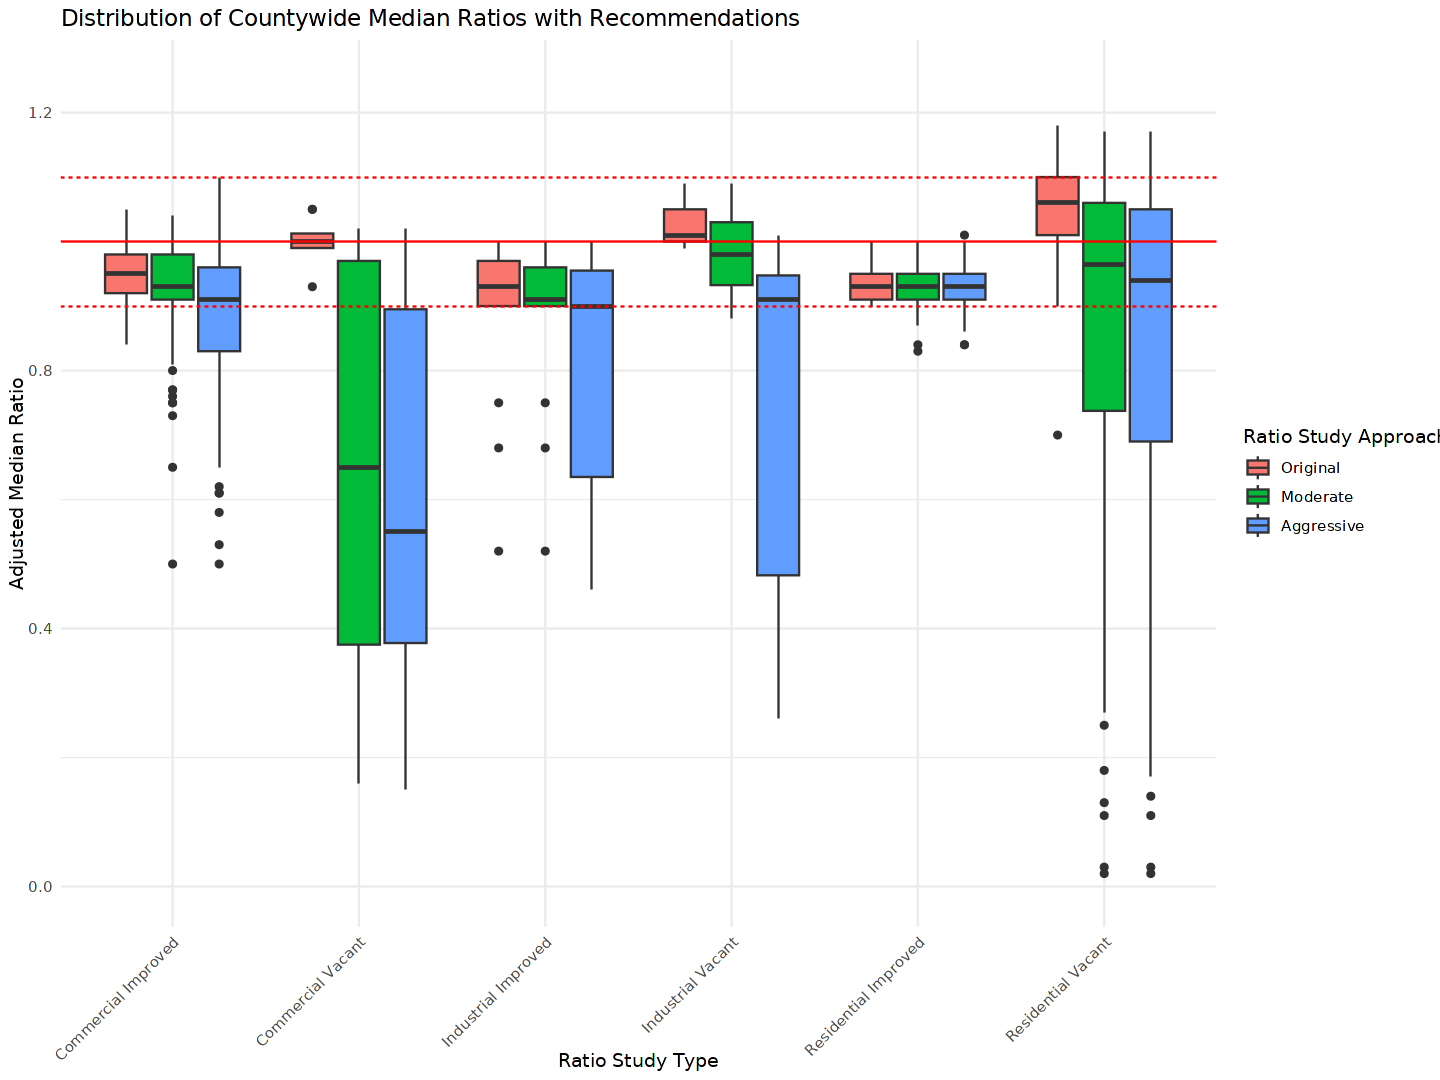

In [ ]:
# Plots the new distribution of countywide median ratios with recommended adjustments
options(repr.plot.width = 12, repr.plot.height = 9)
cresults$Added <- factor(cresults$Added, levels = c("Original", "Moderate", "Aggressive"))
head(cresults)

ggplot(cresults, aes(x = Type, y = Median, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Distribution of Countywide Median Ratios with Recommendations",
       x = "Ratio Study Type",
       y = "Adjusted Median Ratio",
       fill = "Ratio Study Approach") +
  geom_hline(yintercept = 1,color='red') +
  geom_hline(yintercept = 0.9,linetype = 'dashed',color='red') +
  geom_hline(yintercept = 1.1,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ylim(0,1.25) #+
  #coord_flip()

,County,Type,Grouping,LowerBound,Median,UpperBound,COD,COV,PRD,PRB,Sales,Added
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,,Industrial Vacant,3,NA,NA,NA,NA,NA,NA,NA,0,Original
df_sp,"Allen, Blackford, Delaware, Wells",Industrial Improved,3,0.72,0.82,1.00,10.20,13.52,1.02,0,5,Original
11,"Allen, Delaware",Commercial Vacant,3,NA,NA,NA,NA,NA,NA,NA,0,Original
2.5%,"Adams, Blackford, Delaware, Grant, Henry, Howard, Huntington, Jay, Tipton, Wabash, Wells",Commercial Improved,3,0.90,0.96,0.98,22.24,75.47,1.08,0,110,Original
2.5%1,"Adams, Allen, Blackford, Delaware, Henry, Howard, Huntington, Tipton, Wayne, Wells",Residential Vacant,3,1.04,1.10,1.14,19.57,31.22,1.12,0,58,Original
2.5%2,"Adams, Henry, Howard, Huntington, Jay, Randolph, Wells, Allen, Blackford, Delaware, Grant, Hamilton, Madison, Miami, Tipton, Wabash, Wayne",Residential Improved,3,0.95,0.96,0.96,13.76,40.37,1.03,0,4729,Original


Warning message:
"Removed 28 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


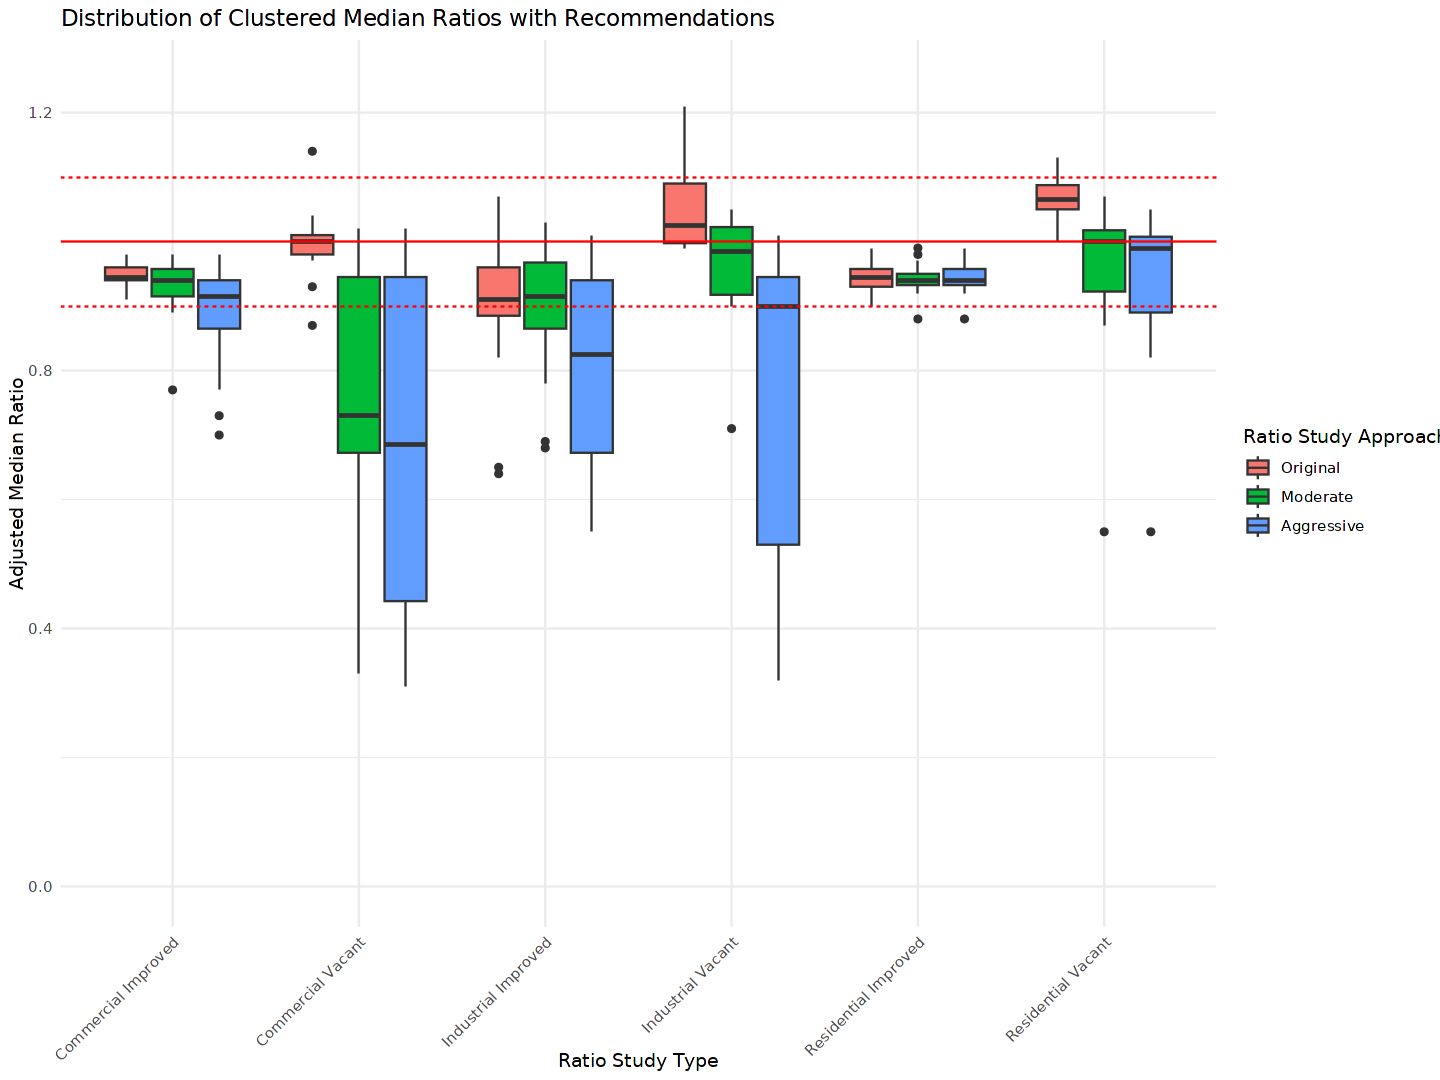

In [ ]:
# Plots the new distribution of clustered median ratios with recommended adjustments
cresults_cl$Added <- factor(cresults_cl$Added, levels = c("Original", "Moderate", "Aggressive"))
head(cresults)

ggplot(cresults_cl, aes(x = Type, y = Median, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Distribution of Clustered Median Ratios with Recommendations",
       x = "Ratio Study Type",
       y = "Adjusted Median Ratio",
       fill = "Ratio Study Approach") +
  geom_hline(yintercept = 1,color='red') +
  geom_hline(yintercept = 0.9,linetype = 'dashed',color='red') +
  geom_hline(yintercept = 1.1,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ylim(0,1.25) #+
#coord_flip()

Warning message:
"Removed 36 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


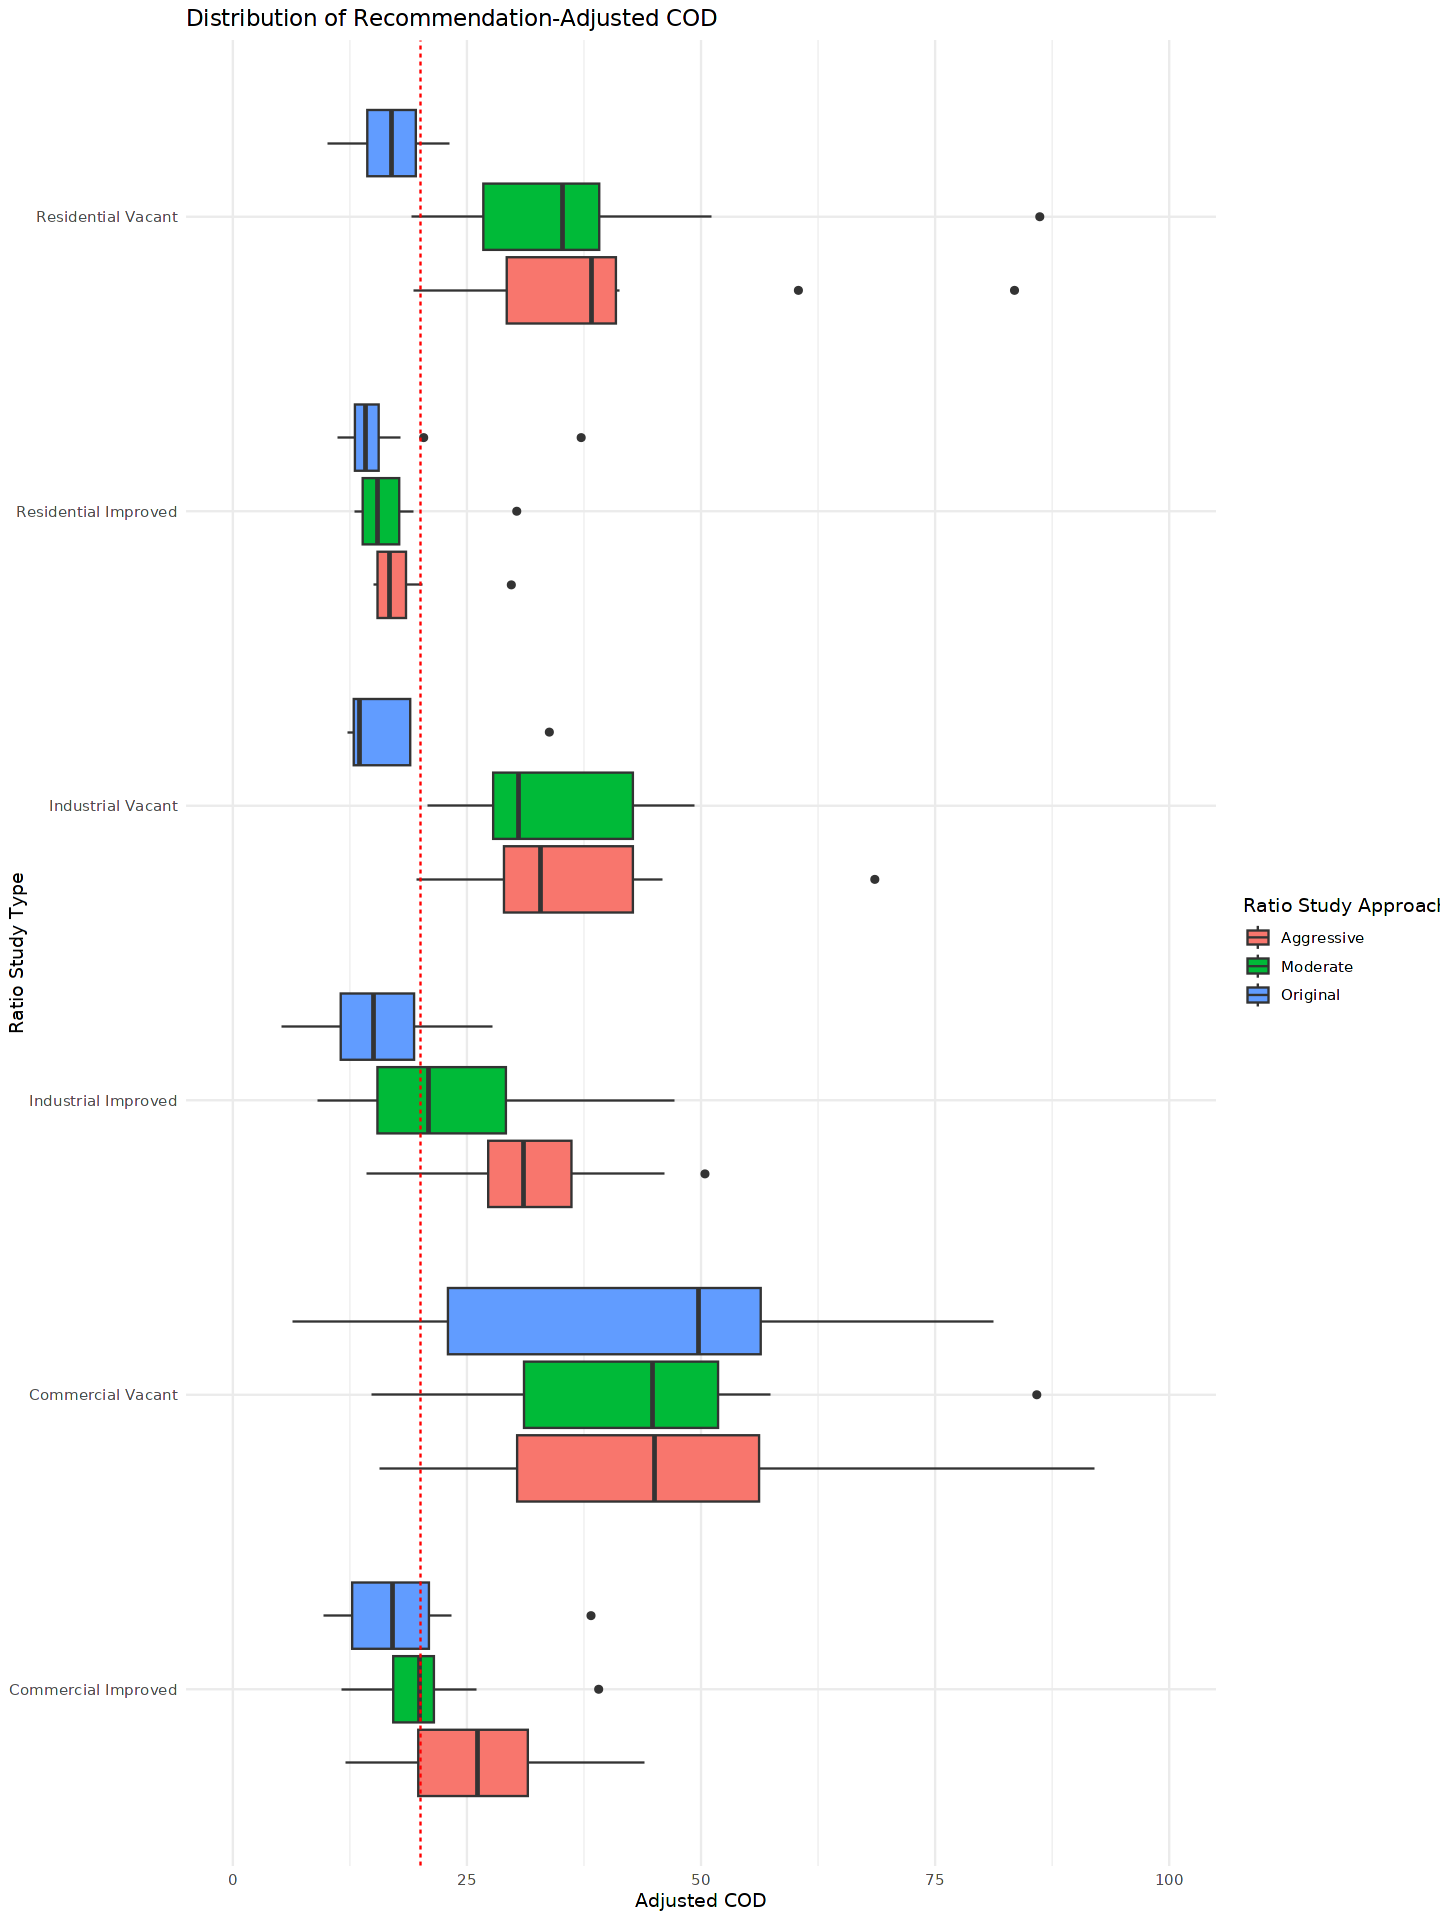

In [ ]:
# Plots the new distribution of countywide COD with recommended adjustments
ggplot(cresults, aes(x = Type, y = COD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0,100) +
  labs(title = "Distribution of Recommendation-Adjusted COD",
       x = "Ratio Study Type",
       y = "Adjusted COD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 20,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

In [ ]:
# Plots the new distribution of clustered COD with recommended adjustments
ggplot(cresults_cl, aes(x = Type, y = COD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0,100) +
  labs(title = "Distribution of Recommendation-Adjusted Clustered COD",
       x = "Ratio Study Type",
       y = "Adjusted COD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 20,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

Warning message:
"Removed 86 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


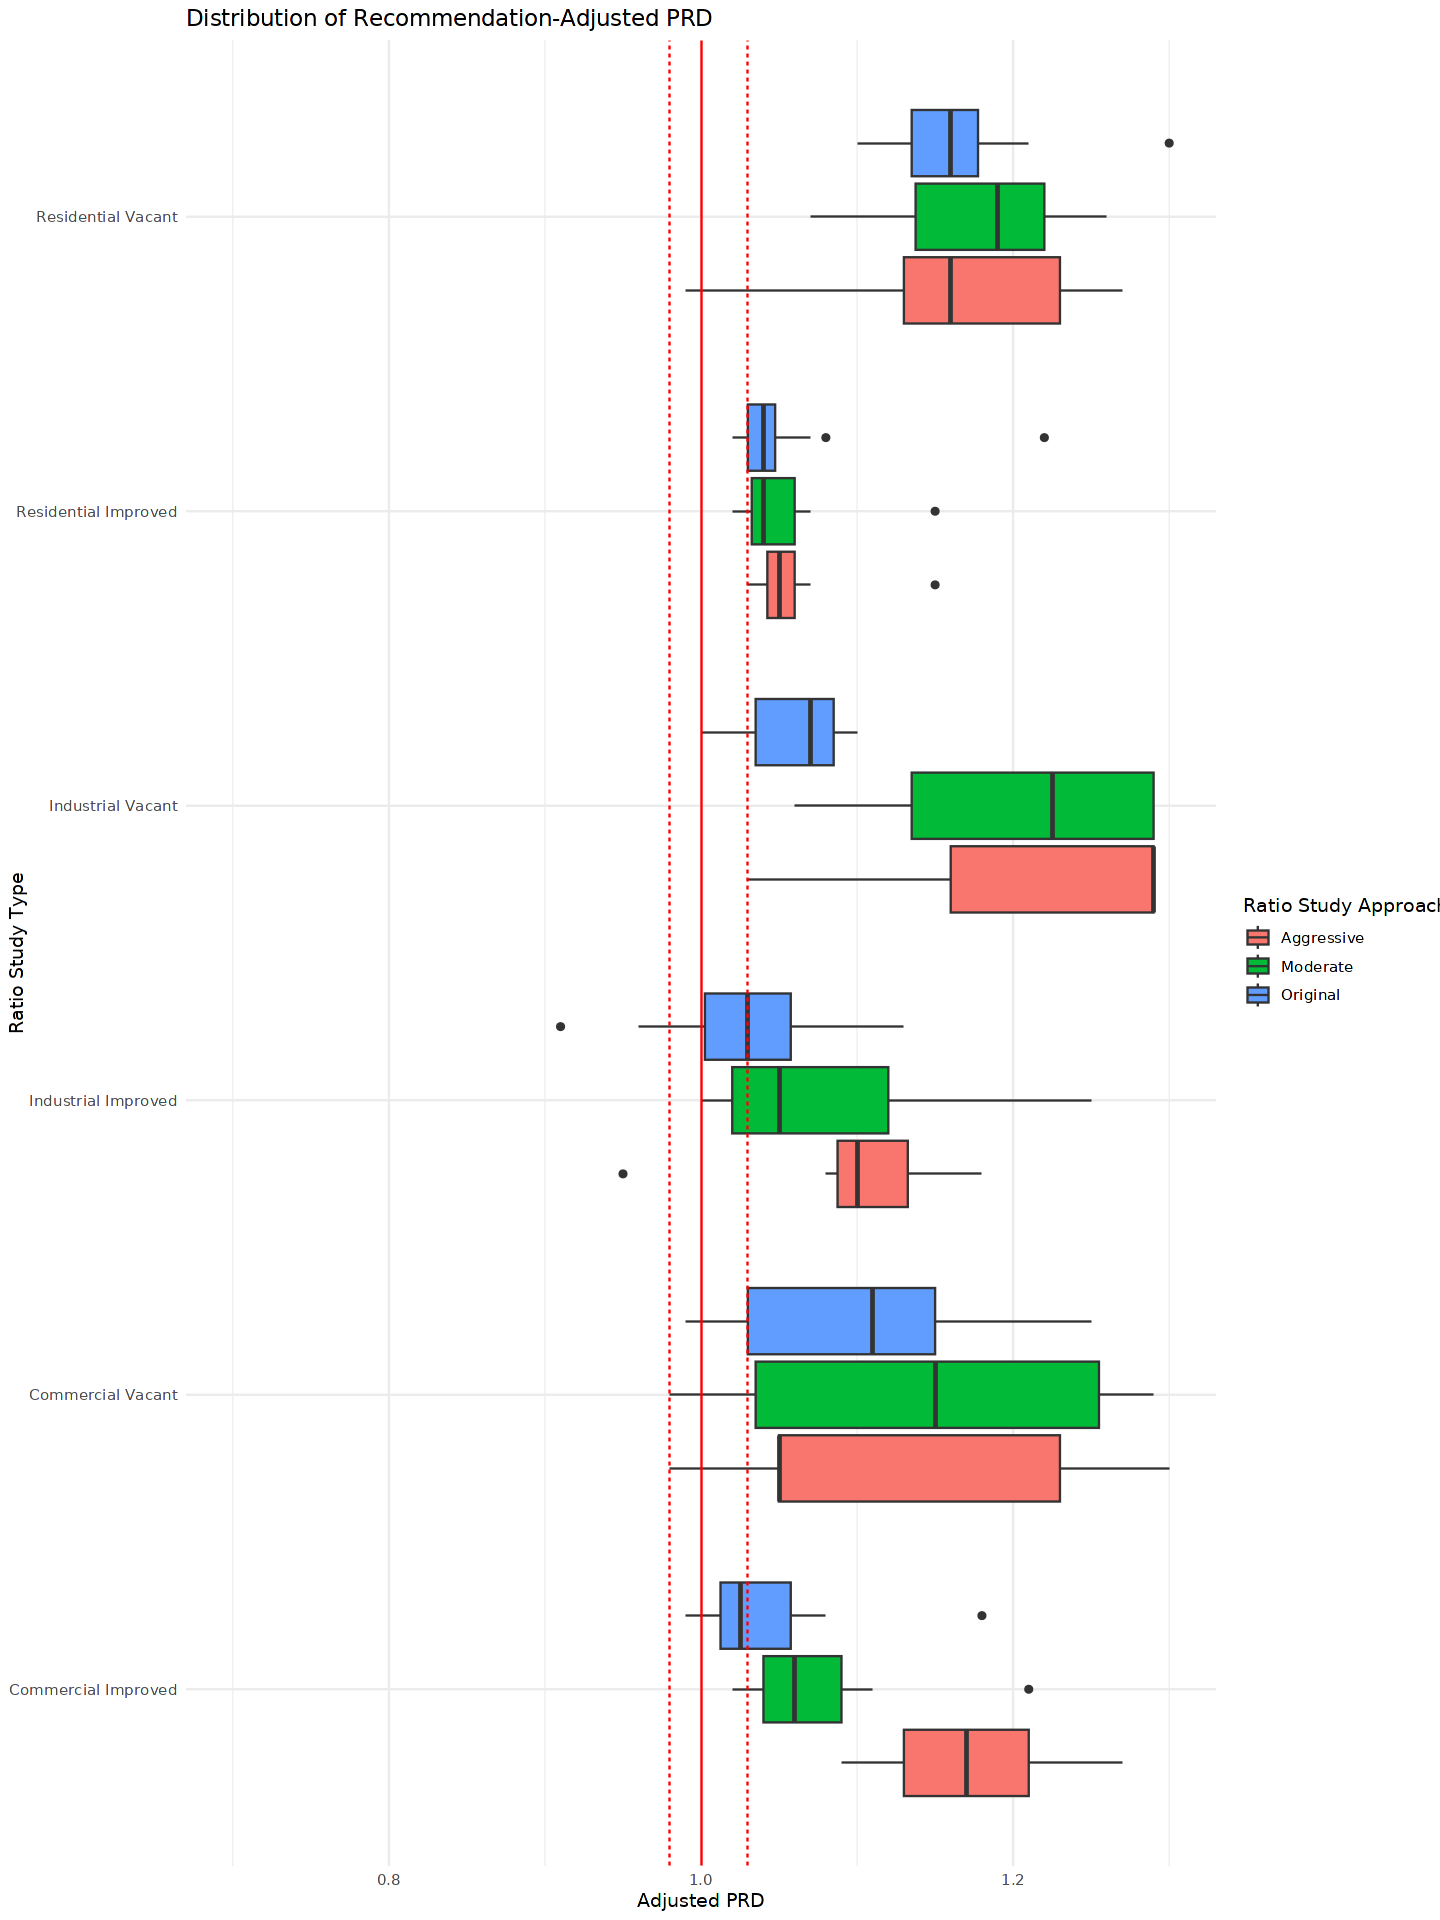

In [ ]:
# Plots the new distribution of countywide PRD with recommended adjustments
ggplot(cresults, aes(x = Type, y = PRD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0.7,1.3) + 
  labs(title = "Distribution of Recommendation-Adjusted PRD",
       x = "Ratio Study Type",
       y = "Adjusted PRD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 1,color='red') +
geom_hline(yintercept = 0.98,linetype = 'dashed',color='red') +
geom_hline(yintercept = 1.03,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()

In [ ]:
# Plots the new distribution of clustered PRD with recommended adjustments
ggplot(cresults_cl, aes(x = Type, y = PRD, fill = Added)) +
  geom_boxplot() +
  theme_minimal() +
ylim(0.7,1.3) + 
  labs(title = "Distribution of Recommendation-Adjusted Clustered PRD",
       x = "Ratio Study Type",
       y = "Adjusted PRD",
       fill = "Ratio Study Approach") +
geom_hline(yintercept = 1,color='red') +
geom_hline(yintercept = 0.98,linetype = 'dashed',color='red') +
geom_hline(yintercept = 1.03,linetype = 'dashed',color='red') +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
coord_flip()